# RoboReviews 
**Project:** Product Review Aggregator powered by NLP  
**Goal:** Build a smooth, linked workflow from raw Amazon reviews to sentiment classification, product clustering, and review-based article generation.

---
## Pipeline Overview
1. **Data loading:** Merge the three review datasets using a shared column set.
2. **Preprocessing:** Deduplicate, clean review text, create rating-based sentiment labels, assign broad meta-categories, and split train/test.
3. **Task 1 — Sentiment classification:** Evaluate zero-shot, n-shot, and LoRA fine-tuned LLM classifiers.
4. **Task 1 handoff:** Create one downstream `task1_sentiment` column, using LoRA predictions where available and rating-derived labels as fallback.
5. **Task 2 — Product clustering:** Compare TF-IDF and sentence-embedding K-Means; choose the better clustering result.
6. **Task 2 handoff:** Merge product cluster labels back into the review-level dataframe and create readable cluster profiles.
7. **Task 3 — Article generation:** Generate articles from Task 2 cluster/category profiles using positive and complaint-oriented review evidence.
8. **Final summary:** Save metrics, generated articles, cluster lookup files, and a compact results JSON.


## 1. Setup & Imports

### Run Note

This notebook intentionally has cleared outputs. Run from top to bottom to regenerate all figures, metrics, and output files from the cleaned pipeline.

In [1]:
# Install required libraries (run once)
import sys
!{sys.executable} -m pip install transformers torch scikit-learn pandas numpy matplotlib seaborn datasets sentencepiece accelerate rouge-score peft trl bitsandbytes sentence-transformers statsmodels --break-system-packages -q



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import gc
import warnings
warnings.filterwarnings('ignore')

import torch
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer
from transformers import pipeline as hf_pipeline

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              precision_recall_fscore_support, f1_score,
                              silhouette_score)
from sklearn.metrics import davies_bouldin_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

from sentence_transformers import SentenceTransformer
from rouge_score import rouge_scorer

# Device detection (CUDA > MPS > CPU)
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Using device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option('display.max_colwidth', 100)
sns.set_theme(style='whitegrid')
print('All imports OK')


Using device: mps
All imports OK


## 2. Load & Merge Datasets

In [3]:
FILES = [
    '1429_1.csv',
    'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv',
    'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv',
]

# Only load columns useful for the project — saves memory on large files
COMMON_COLS = [
    'id', 'name', 'brand', 'categories',
    'reviews.date', 'reviews.rating', 'reviews.text', 'reviews.title',
    'reviews.doRecommend', 'reviews.numHelpful', 'reviews.username',
    'reviews.sourceURLs',
]

dfs = []
for f in FILES:
    df_tmp = pd.read_csv(f, low_memory=False, usecols=lambda c: c in COMMON_COLS)
    print(f'{f}: {len(df_tmp):,} rows loaded')   
    dfs.append(df_tmp)                             

# Concatenate all files into one DataFrame
raw = pd.concat(dfs, ignore_index=True)
print(f'\nTotal combined: {len(raw):,} rows')


1429_1.csv: 34,660 rows loaded
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv: 28,332 rows loaded
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv: 5,000 rows loaded

Total combined: 67,992 rows


In [4]:
before = len(raw)
raw = raw.drop_duplicates(subset='reviews.text')
after = len(raw)
print(f'Removed {before - after:,} duplicate reviews → {after:,} unique reviews remaining')

Removed 21,082 duplicate reviews → 46,910 unique reviews remaining


## 3. Exploratory Data Analysis (EDA)

In [5]:
print('=== Dataset Shape ===')
print(f'Rows: {raw.shape[0]:,} | Columns: {raw.shape[1]}')
print('\n=== Missing Values ===')
print(raw.isnull().sum())
print('\n=== Data Types ===')
print(raw.dtypes)

=== Dataset Shape ===
Rows: 46,910 | Columns: 12

=== Missing Values ===
id                        0
name                   6760
brand                     0
categories                0
reviews.date             39
reviews.doRecommend    9594
reviews.numHelpful     9506
reviews.rating           33
reviews.sourceURLs        0
reviews.text              1
reviews.title            17
reviews.username          7
dtype: int64

=== Data Types ===
id                         str
name                       str
brand                      str
categories                 str
reviews.date               str
reviews.doRecommend     object
reviews.numHelpful     float64
reviews.rating         float64
reviews.sourceURLs         str
reviews.text               str
reviews.title              str
reviews.username           str
dtype: object


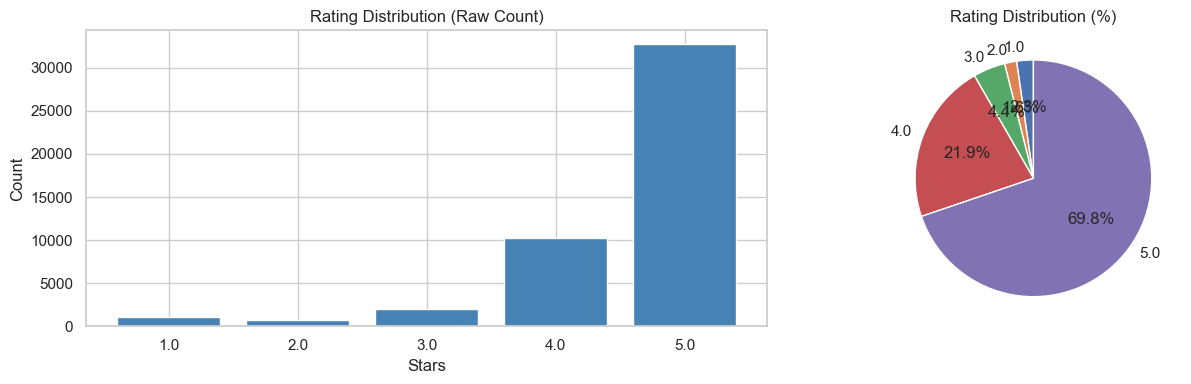

 Notice: Heavy class imbalance — 5-star reviews dominate!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

rating_counts = raw['reviews.rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(str), rating_counts.values, color='steelblue')
axes[0].set_title('Rating Distribution (Raw Count)')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Count')

axes[1].pie(rating_counts.values, labels=rating_counts.index.astype(str),
autopct='%1.1f%%', startangle=90)
axes[1].set_title('Rating Distribution (%)')

plt.tight_layout()
plt.show()
print(' Notice: Heavy class imbalance — 5-star reviews dominate!')

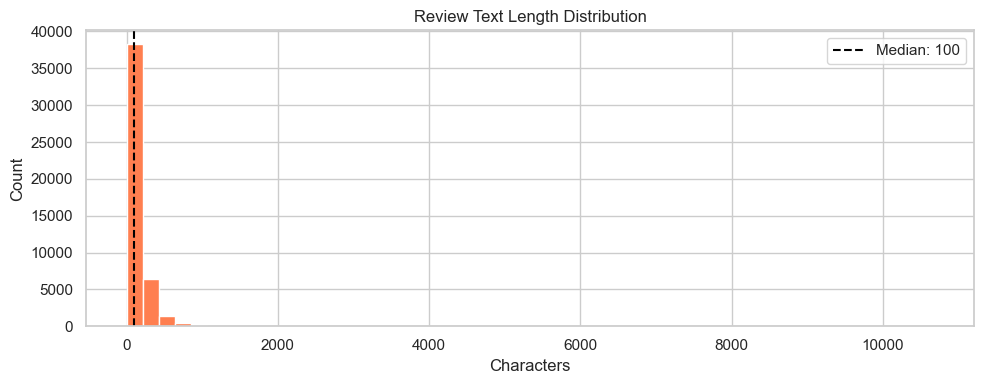

In [7]:
raw['text_length'] = raw['reviews.text'].dropna().apply(len)

plt.figure(figsize=(10, 4))
plt.hist(raw['text_length'].dropna(), bins=50, color='coral', edgecolor='white')
plt.title('Review Text Length Distribution')
plt.xlabel('Characters')
plt.ylabel('Count')
plt.axvline(raw['text_length'].median(), color='black', linestyle='--',
label=f'Median: {raw["text_length"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

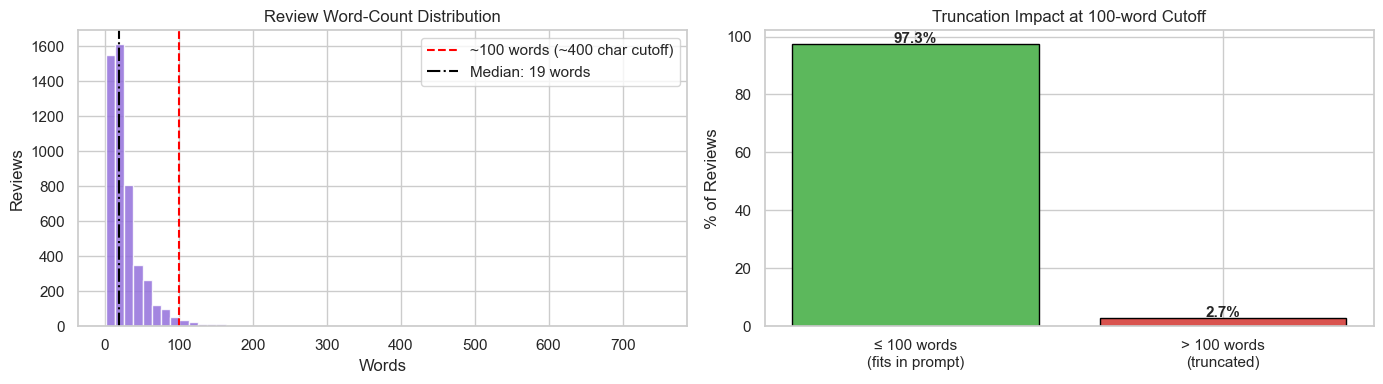

2.7% of reviews exceed the ~100-word prompt truncation limit.
Tip: consider raising the cutoff on GPU, or summarising very long reviews first.


In [8]:
# ─── Token-length distribution ───────────────────────────────────────────────
sample_tok = raw['reviews.text'].dropna().sample(n=min(5000, len(raw)), random_state=SEED)
word_counts = sample_tok.apply(lambda t: len(str(t).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(word_counts, bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[0].axvline(100, color='red', linestyle='--', label='~100 words (~400 char cutoff)')
axes[0].axvline(word_counts.median(), color='black', linestyle='-.',
                label=f'Median: {word_counts.median():.0f} words')
axes[0].set_title('Review Word-Count Distribution')
axes[0].set_xlabel('Words'); axes[0].set_ylabel('Reviews'); axes[0].legend()

pct_cut = (word_counts > 100).mean() * 100
axes[1].bar(['≤ 100 words\n(fits in prompt)', '> 100 words\n(truncated)'],
            [100 - pct_cut, pct_cut],
            color=['#5cb85c', '#d9534f'], edgecolor='black')
axes[1].set_title('Truncation Impact at 100-word Cutoff')
axes[1].set_ylabel('% of Reviews')
for i, v in enumerate([100 - pct_cut, pct_cut]):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()
print(f'{pct_cut:.1f}% of reviews exceed the ~100-word prompt truncation limit.')
print('Tip: consider raising the cutoff on GPU, or summarising very long reviews first.')

In [9]:
print('Top 10 products by review count:')
print(raw['name'].value_counts().head(10).to_string())

Top 10 products by review count:
name
Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta                                       10966
AmazonBasics AAA Performance Alkaline Batteries (36 Count)                                                    7427
Echo (White),,,\r\nEcho (White),,,                                                                            3309
Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,,     3176
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta                       2814
Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,                                                                        2527
Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case                                       1685
AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary                                1418
Brand New Amazon Kindle Fire 16gb 7 Ips Di

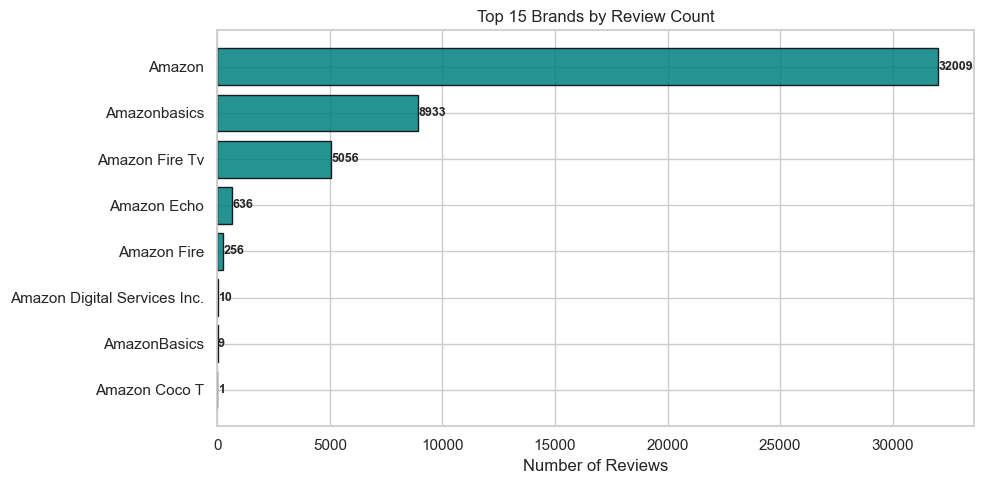

In [10]:
# ─── Top brands by review volume ─────────────────────────────────────────────
top_brands = raw['brand'].dropna().value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_brands.index[::-1], top_brands.values[::-1], color='teal', edgecolor='black', alpha=0.85)
ax.set_title('Top 15 Brands by Review Count')
ax.set_xlabel('Number of Reviews')
for i, v in enumerate(top_brands.values[::-1]):
    ax.text(v + 20, i, str(v), va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Split comma-separated category strings and count individual tags
cat_series = raw['categories'].dropna().str.split(',').explode().str.strip()
print('Top 30 raw category tags:')
print(cat_series.value_counts().head(30).to_string())

Top 30 raw category tags:
categories
Electronics             52873
Computers & Tablets     23614
Tablets                 23269
All Tablets             19773
Electronics Features    19293
iPad & Tablets          18094
Fire Tablets            18017
Health                  17690
Home                    14617
Kindle Store            12901
Amazon Devices          12743
Featured Brands         12694
TVs Entertainment       12448
Tech Toys               11692
Movies                  11692
Music                   11692
Holiday Shop            11690
Frys                    11627
Android Tablets         11048
Accessories              8926
AA                       8845
AAA                      8845
Health & Household       8845
Camcorder Batteries      8845
Camera & Photo           8845
Batteries                8845
Household Batteries      8845
Camera Batteries         8845
Health and Beauty        8845
Household Supplies       8845


## 4. Preprocessing

In [12]:
df = raw.dropna(subset=['reviews.text', 'reviews.rating']).copy()
print(f'After dropping nulls: {len(df):,} rows')

After dropping nulls: 46,876 rows


In [13]:
def clean_text(text: str) -> str:
    """Basic text cleaning: remove HTML, URLs, non-ASCII, and extra whitespace."""
    text = str(text)
    text = re.sub(r'<[^>]+>', ' ', text) # remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text) # remove URLs
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # remove non-ASCII characters
    text = re.sub(r'\s+', ' ', text).strip() # collapse multiple spaces into one

    return text

df['clean_text'] = df['reviews.text'].apply(clean_text)

# Filter out reviews that are too short to carry any meaning
df = df[df['clean_text'].str.len() >= 10].copy()
print(f'After text cleaning: {len(df):,} rows')

# Leakage fix: remove duplicates AFTER cleaning, before any train/test split.
# Some reviews differ only by formatting/URLs/non-ASCII characters, so raw-text
# deduplication alone can leave the same cleaned review in both train and test.
before_clean_dedup = len(df)
df = df.drop_duplicates(subset='clean_text').copy()
removed_clean_dupes = before_clean_dedup - len(df)
print(f'Removed {removed_clean_dupes:,} duplicate cleaned reviews before splitting')

print('\nSample cleaned review:')
print(df['clean_text'].iloc[0])


After text cleaning: 46,604 rows
Removed 66 duplicate cleaned reviews before splitting

Sample cleaned review:
This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.


### Leakage Prevention Note
Cleaned review text is deduplicated before the train/test split. This prevents the same normalized review from appearing in both Task 1 training and evaluation sets.


In [14]:
def rating_to_sentiment(rating: float) -> str:
    """Convert a 1-5 star rating into a 3-class sentiment label."""
    
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['reviews.rating'].apply(rating_to_sentiment)

print('Sentiment distribution (counts):')
print(df['sentiment'].value_counts())
print()
print('Sentiment distribution (%):')
print((df['sentiment'].value_counts(normalize=True) * 100).round(1))

Sentiment distribution (counts):
sentiment
positive    42671
neutral      2038
negative     1829
Name: count, dtype: int64

Sentiment distribution (%):
sentiment
positive    91.7
neutral      4.4
negative     3.9
Name: proportion, dtype: float64


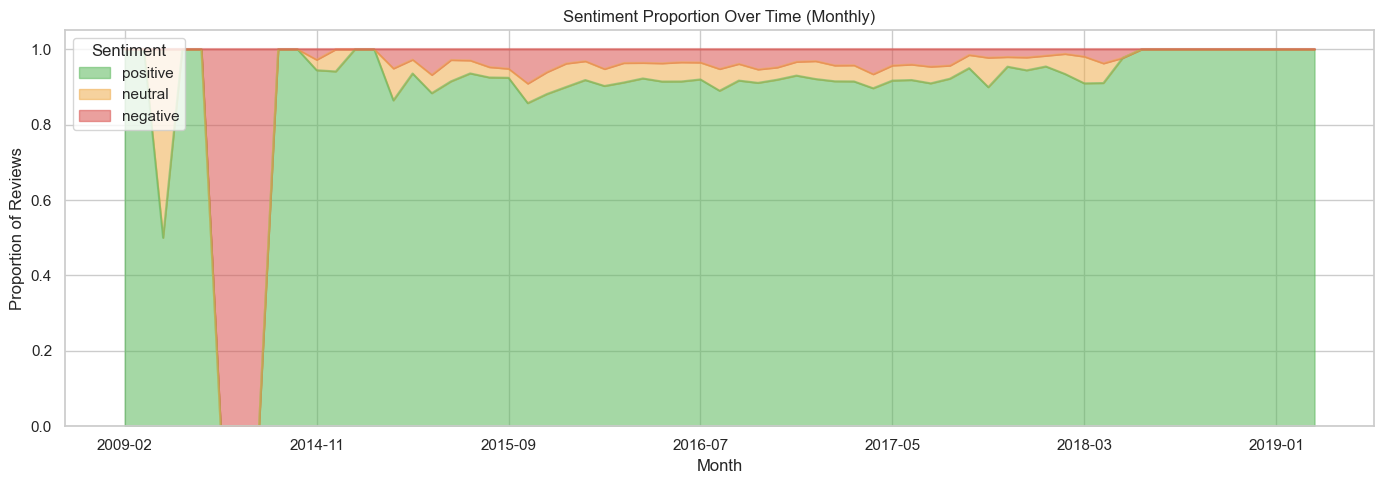

Top 10 brands by sentiment score (min 20 reviews):
                avg_score  review_count
brand                                  
Amazon Fire Tv   0.943960          5050
Amazon           0.906539         31885
Amazon Fire      0.886275           255
Amazon Echo      0.878740           635
Amazonbasics     0.733264          8694

Bottom 10 brands:
                avg_score  review_count
brand                                  
Amazon Fire Tv   0.943960          5050
Amazon           0.906539         31885
Amazon Fire      0.886275           255
Amazon Echo      0.878740           635
Amazonbasics     0.733264          8694


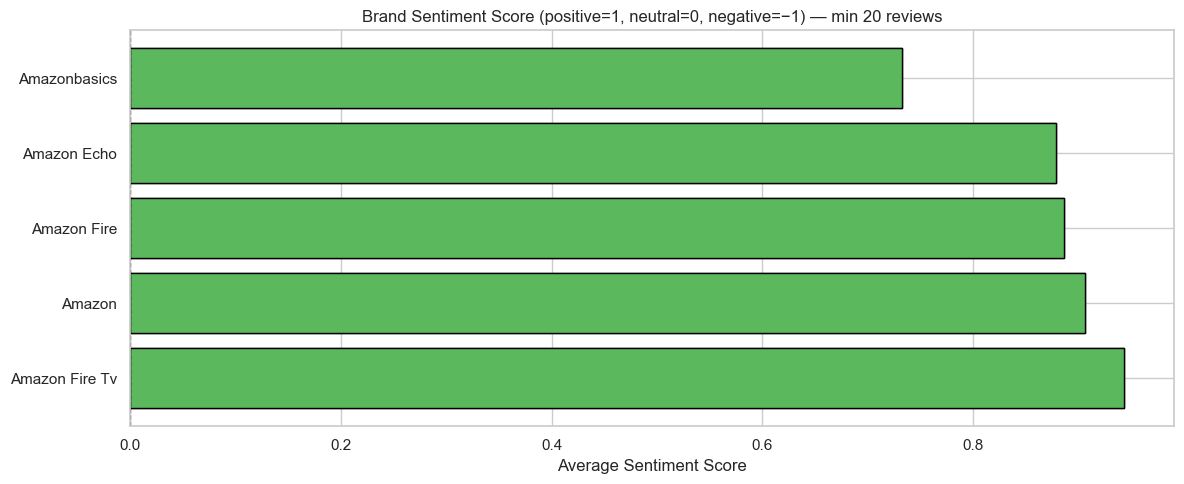

In [15]:
# ─── Temporal sentiment trend ─────────────────────────────────────────────────
_tmp = df.copy()
_tmp['reviews.date'] = pd.to_datetime(_tmp['reviews.date'], errors='coerce')
_tmp = _tmp.dropna(subset=['reviews.date'])
_tmp['year_month'] = _tmp['reviews.date'].dt.to_period('M').astype(str)

if len(_tmp) > 100:
    monthly_sent = (
        _tmp.groupby('year_month')['sentiment']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .sort_index()
    )
    ordered_cols = [c for c in ['positive', 'neutral', 'negative'] if c in monthly_sent.columns]
    if len(monthly_sent) >= 4:
        monthly_sent[ordered_cols].plot(
            kind='area', figsize=(14, 5), alpha=0.55,
            color=['#5cb85c', '#f0ad4e', '#d9534f'][:len(ordered_cols)]
        )
        plt.title('Sentiment Proportion Over Time (Monthly)')
        plt.xlabel('Month'); plt.ylabel('Proportion of Reviews')
        plt.legend(title='Sentiment', loc='upper left')
        plt.tight_layout(); plt.show()
    else:
        print('Too few months for a meaningful temporal plot.')
else:
    print('Not enough date-stamped reviews for temporal analysis.')

# ─── Brand-level average sentiment score ─────────────────────────────────────
df['sentiment_score'] = df['sentiment'].map({'positive': 1, 'neutral': 0, 'negative': -1})
brand_sent = (
    df.groupby('brand')
    .agg(avg_score=('sentiment_score', 'mean'), review_count=('sentiment_score', 'count'))
    .query('review_count >= 20')
    .sort_values('avg_score', ascending=False)
)
print('Top 10 brands by sentiment score (min 20 reviews):')
print(brand_sent.head(10).to_string())
print('\nBottom 10 brands:')
print(brand_sent.tail(10).to_string())

top_bottom = pd.concat([brand_sent.head(8), brand_sent.tail(8)])
colors_bb = ['#5cb85c' if v >= 0 else '#d9534f' for v in top_bottom['avg_score']]

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_bottom.index, top_bottom['avg_score'], color=colors_bb, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.9, linestyle='--')
ax.set_title('Brand Sentiment Score (positive=1, neutral=0, negative=−1) — min 20 reviews')
ax.set_xlabel('Average Sentiment Score')
plt.tight_layout(); plt.show()

In [16]:
# Each tuple: (meta-category name, list of keywords to match against product name + categories)
META_CATEGORY_RULES = [
    ('E-Readers & Tablets', ['kindle', 'fire tablet', 'e-reader', 'ebook', 'paperwhite', 'tablet', 'ipad']),
    ('Smart Home & Audio', ['echo', 'alexa', 'fire tv', 'speaker', 'audio', 'headphone', 'bluetooth']),
    ('Batteries & Power', ['battery', 'batteries', 'charger', 'power', 'usb', 'adapter']),
    ('Accessories', ['case', 'keyboard', 'stand', 'mount', 'cable', 'screen protector', 'stylus', 'accessory']),
    ('Health & Beauty', ['health', 'beauty', 'nespresso', 'coffee', 'pet', 'toy', 'game']),
]

def assign_meta_category(name: str, categories: str) -> str:
    """Assign a broad meta-category by checking product name and category tags."""
    text = f"{str(name)} {str(categories)}".lower()
    for meta, keywords in META_CATEGORY_RULES:
        if any(kw in text for kw in keywords):
            return meta
    return 'Other'

df['meta_category'] = df.apply(
    lambda r: assign_meta_category(r['name'], r['categories']), axis=1
)

print('Meta-category distribution:')
print(df['meta_category'].value_counts())


Meta-category distribution:
meta_category
E-Readers & Tablets    36472
Batteries & Power       8620
Smart Home & Audio      1403
Accessories               28
Other                     10
Health & Beauty            5
Name: count, dtype: int64


In [17]:
# Stratifying by sentiment keeps the rare negative/neutral classes represented in both splits.
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df['sentiment'],
)

print(f'Train: {len(train_df):,} rows')
print(f'Test: {len(test_df):,} rows')

# Verify that no cleaned review text appears in both train and test.
train_texts = set(train_df['clean_text'].dropna())
test_texts = set(test_df['clean_text'].dropna())
overlap_texts = train_texts.intersection(test_texts)
assert len(overlap_texts) == 0, f'Data leakage detected: {len(overlap_texts)} cleaned reviews appear in both train and test.'
print('Leakage check passed: 0 duplicate clean_text values across train/test.')

print('\nTrain sentiment distribution:')
print(train_df['sentiment'].value_counts())
print('\nTest sentiment distribution:')
print(test_df['sentiment'].value_counts())


Train: 37,230 rows
Test: 9,308 rows
Leakage check passed: 0 duplicate clean_text values across train/test.

Train sentiment distribution:
sentiment
positive    34137
neutral      1630
negative     1463
Name: count, dtype: int64

Test sentiment distribution:
sentiment
positive    8534
neutral      408
negative     366
Name: count, dtype: int64


In [18]:
df.to_csv('reviews_preprocessed.csv', index=False)
train_df.to_csv('reviews_train.csv', index=False)
test_df.to_csv('reviews_test.csv', index=False)
print('Preprocessed files saved ')
print(' - reviews_preprocessed.csv (full dataset)')
print(' - reviews_train.csv')
print(' - reviews_test.csv')

Preprocessed files saved 
 - reviews_preprocessed.csv (full dataset)
 - reviews_train.csv
 - reviews_test.csv


### Preprocessing Handoff Check

This cell verifies that preprocessing produced the exact files and columns needed downstream. Task 1 uses `clean_text` and `sentiment`; Task 2 and Task 3 also use `name`, `categories`, `meta_category`, and review text.

In [19]:
required_cols = {'name', 'categories', 'reviews.rating', 'clean_text', 'sentiment', 'meta_category'}
missing_cols = required_cols - set(df.columns)
assert not missing_cols, f'Missing required columns after preprocessing: {missing_cols}'
assert len(train_df) + len(test_df) == len(df), 'Train/test split row counts do not add up.'
assert train_df['clean_text'].notna().all() and test_df['clean_text'].notna().all(), 'Null clean_text found.'
_text_overlap = set(train_df['clean_text']).intersection(set(test_df['clean_text']))
assert len(_text_overlap) == 0, f'Data leakage detected after split: {len(_text_overlap)} duplicate clean_text values.'

handoff_summary = pd.DataFrame({
    'dataset': ['full', 'train', 'test'],
    'rows': [len(df), len(train_df), len(test_df)],
    'positive': [
        (df['sentiment'] == 'positive').sum(),
        (train_df['sentiment'] == 'positive').sum(),
        (test_df['sentiment'] == 'positive').sum(),
    ],
    'neutral': [
        (df['sentiment'] == 'neutral').sum(),
        (train_df['sentiment'] == 'neutral').sum(),
        (test_df['sentiment'] == 'neutral').sum(),
    ],
    'negative': [
        (df['sentiment'] == 'negative').sum(),
        (train_df['sentiment'] == 'negative').sum(),
        (test_df['sentiment'] == 'negative').sum(),
    ],
})

print('Preprocessing handoff validated.')
display(handoff_summary)


Preprocessing handoff validated.


,dataset,rows,positive,neutral,negative
0,full,46538,42671,2038,1829
1,train,37230,34137,1630,1463
2,test,9308,8534,408,366


## 5. Task 1 — Sentiment Classification (LLM Baseline)

In [20]:
CLF_MODEL = 'Qwen/Qwen2.5-1.5B-Instruct'

print(f'Loading classifier LLM: {CLF_MODEL}')
print('First run downloads model weights — may take a few minutes...')

clf_pipeline = pipeline(
    'text-generation',
    model=CLF_MODEL,
    device=0 if DEVICE == 'cuda' else -1,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
)
print('Model loaded')


Loading classifier LLM: Qwen/Qwen2.5-1.5B-Instruct
First run downloads model weights — may take a few minutes...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:03<00:00, 104.78it/s]


Model loaded


In [21]:
SYSTEM_PROMPT = (
"""
You are a strict Amazon product review sentiment classifier.

Classify into exactly one label:
- negative: clearly unhappy, complaint, broken, returned, disappointed, poor quality
- positive: clearly happy, recommends, works well, loves it
- neutral: mixed, average, okay, acceptable, factual, has both pros and cons, or mild praise with caveats

Important:
If the review has both positive and negative signals, choose neutral.
If the review sounds lukewarm, choose neutral.
Return only one word: negative, neutral, or positive.
"""
)

def build_clf_prompt(review_text: str) -> str:
    """Format a review into a chat-style prompt for the LLM classifier."""
    return (
    f'<|system|>\n{SYSTEM_PROMPT}\n'
    f'<|user|>\nReview: {review_text[:400]}\n' # truncate to 400 chars to keep prompts short
    f'<|assistant|>\n'
    )

def parse_sentiment(output: str) -> str:
    text = output.lower().strip()
    match = re.search(r"\b(negative|neutral|positive)\b", text)
    if match:
        return match.group(1)
    return "neutral"

# Sanity check with a clearly positive review
test_review = 'I absolutely love this product, it works perfectly and arrived fast!'
test_prompt = build_clf_prompt(test_review)
test_out = clf_pipeline(test_prompt, max_new_tokens=10, do_sample=False)
generated = test_out[0]['generated_text'].replace(test_prompt, '').strip()
print(f'Sanity check → "{test_review[:60]}"')
print(f'LLM output: "{generated}" → Parsed: "{parse_sentiment(generated)}"')

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Sanity check → "I absolutely love this product, it works perfectly and arriv"
LLM output: "positive" → Parsed: "positive"


In [22]:
FEW_SHOT_EXAMPLES = """\
Review: "I absolutely love this Kindle! Battery lasts weeks and screen is crystal clear."
Sentiment: positive

Review: "Best purchase this year. Arrived fast and works perfectly out of the box."
Sentiment: positive

Review: "Stopped working after 3 days. Complete waste of money, very disappointed."
Sentiment: negative

Review: "Poor build quality, nothing like described. Returned immediately."
Sentiment: negative

Review: "It's okay for the price. Does what it says but nothing impressive."
Sentiment: neutral

Review: "Average product. Some good things, some bad. Wouldn't strongly recommend or avoid."
Sentiment: neutral

Review: "Some features are great but others are disappointing. Mixed feelings."
Sentiment: neutral

Review: "Decent quality but had some issues with setup. Works fine now though."
Sentiment: neutral
"""

def build_clf_prompt_nshot(review_text: str) -> str:
    return (
        f"<|system|>\n{SYSTEM_PROMPT}\n"
        f"<|user|>\n"
        f"Examples:\n\n"
        f"{FEW_SHOT_EXAMPLES}\n"
        f"Now classify this review.\n"
        f"Review: {review_text[:600]}\n"
        f"<|assistant|>\n"
    )

SAMPLE_SIZE = 300
n_per_class = SAMPLE_SIZE // 3
frames = []
for sentiment_class in ['negative', 'neutral', 'positive']:
    grp = test_df[test_df['sentiment'] == sentiment_class]
    frames.append(grp.sample(n=min(n_per_class, len(grp)), random_state=SEED))
sample_df = pd.concat(frames).reset_index(drop=True)

print(f'Sample size: {len(sample_df)}')
print(sample_df['sentiment'].value_counts())

true_labels = sample_df['sentiment'].tolist()

predictions_nshot = []
for i, text in enumerate(sample_df['clean_text'].tolist()):
    prompt = build_clf_prompt_nshot(text)
    out = clf_pipeline(prompt, max_new_tokens=10, do_sample=False)
    raw_out = out[0]['generated_text'].replace(prompt, '').strip()
    predictions_nshot.append(parse_sentiment(raw_out))

    if (i + 1) % 50 == 0:
        print(f'  {i + 1}/{len(sample_df)} done...')

sample_df['predicted_nshot'] = predictions_nshot
print('N-shot inference complete')

[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Sample size: 300
sentiment
negative    100
neutral     100
positive    100
Name: count, dtype: int64


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  50/300 done...


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

...

  200/300 done...


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  250/300 done...


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  300/300 done...
N-shot inference complete


In [23]:
#Sanity check with a clearly negative review number
test_review = 'It was not as good as i expected!'
test_prompt = build_clf_prompt(test_review)
test_out = clf_pipeline(test_prompt, max_new_tokens=10, do_sample=False)
generated = test_out[0]['generated_text'].replace(test_prompt, '').strip()
print(f'Sanity check → "{test_review[:60]}"')
print(f'LLM output: "{generated}" → Parsed: "{parse_sentiment(generated)}"')

[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Sanity check → "It was not as good as i expected!"
LLM output: "negative" → Parsed: "negative"


In [24]:
#Sanity check with a clearly neutral review number
test_review = 'I dont have an opinion!'
test_prompt = build_clf_prompt(test_review)
test_out = clf_pipeline(test_prompt, max_new_tokens=10, do_sample=False)
generated = test_out[0]['generated_text'].replace(test_prompt, '').strip()
print(f'Sanity check → "{test_review[:60]}"')
print(f'LLM output: "{generated}" → Parsed: "{parse_sentiment(generated)}"')

[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Sanity check → "I dont have an opinion!"
LLM output: "neutral" → Parsed: "neutral"


In [25]:
SAMPLE_SIZE = 300  # 100 per class 

# Take an equal number of reviews from each sentiment class (capped at group size)
n_per_class = SAMPLE_SIZE // 3
frames = []
for sentiment_class in ['negative', 'neutral', 'positive']:
    grp = test_df[test_df['sentiment'] == sentiment_class]
    frames.append(grp.sample(n=min(n_per_class, len(grp)), random_state=SEED))
sample_df = pd.concat(frames).reset_index(drop=True)

true_labels = sample_df['sentiment'].tolist()

print(f'Stratified sample size: {len(sample_df)}')
print(sample_df['sentiment'].value_counts())
print()
print('Running LLM inference... (this may take a few minutes on CPU)')

predictions = []
for i, text in enumerate(sample_df['clean_text'].tolist()):
    prompt = build_clf_prompt(text)
    out = clf_pipeline(prompt, max_new_tokens=10, do_sample=False)
    raw_out = out[0]['generated_text'].replace(prompt, '').strip()
    predictions.append(parse_sentiment(raw_out))

    if (i + 1) % 50 == 0:
        print(f'  {i + 1}/{len(sample_df)} done...')

sample_df = sample_df.copy()
sample_df['predicted_sentiment'] = predictions
print('Inference complete')

[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Stratified sample size: 300
sentiment
negative    100
neutral     100
positive    100
Name: count, dtype: int64

Running LLM inference... (this may take a few minutes on CPU)


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  50/300 done...


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

...

  200/300 done...


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  250/300 done...


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  300/300 done...
Inference complete


## 5.5 Task 1 — Evaluation

In [26]:
LABEL_ORDER = ['negative', 'neutral', 'positive']
true_labels = sample_df['sentiment'].tolist()
pred_labels = sample_df['predicted_sentiment'].tolist()

acc = accuracy_score(true_labels, pred_labels)
print(f'=== Task 1 — LLM Sentiment Classifier zero-shot (Baseline) ===')
print(f'Overall Accuracy: {acc:.4f} ({acc*100:.1f}%)')
print()

print('=== Classification Report ===')
print(classification_report(true_labels, pred_labels, target_names=LABEL_ORDER))
print('-'*75)
acc_n = accuracy_score(true_labels, predictions_nshot)
print(f'=== Task 1 — LLM Sentiment Classifier n-shot ===')
print(f'Overall Accuracy: {acc_n:.4f} ({acc_n*100:.1f}%)')
print()
print('=== Classification Report ===')
print(classification_report(true_labels, predictions_nshot, target_names=LABEL_ORDER))

=== Task 1 — LLM Sentiment Classifier zero-shot (Baseline) ===
Overall Accuracy: 0.6900 (69.0%)

=== Classification Report ===
              precision    recall  f1-score   support

    negative       0.64      0.87      0.73       100
     neutral       0.63      0.31      0.42       100
    positive       0.78      0.89      0.83       100

    accuracy                           0.69       300
   macro avg       0.68      0.69      0.66       300
weighted avg       0.68      0.69      0.66       300

---------------------------------------------------------------------------
=== Task 1 — LLM Sentiment Classifier n-shot ===
Overall Accuracy: 0.7000 (70.0%)

=== Classification Report ===
              precision    recall  f1-score   support

    negative       0.64      0.88      0.74       100
     neutral       0.65      0.32      0.43       100
    positive       0.79      0.90      0.84       100

    accuracy                           0.70       300
   macro avg       0.69      0.

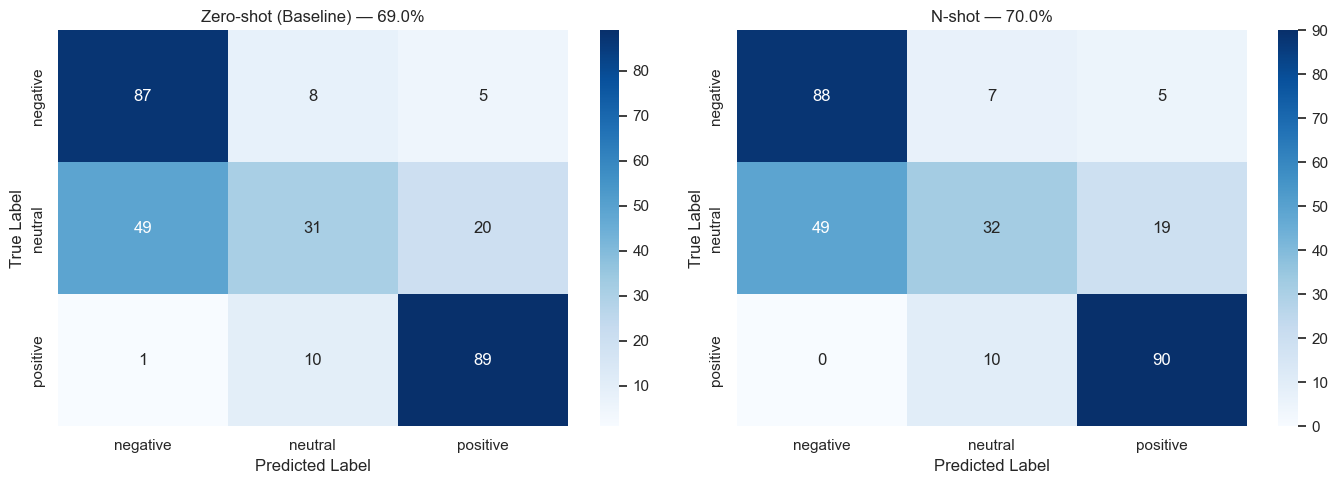

In [27]:
# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acc_zero = accuracy_score(true_labels, pred_labels)
acc_nshot = accuracy_score(true_labels, predictions_nshot)

for ax, preds, title in zip(
    axes,
    [pred_labels, predictions_nshot],
    [f'Zero-shot (Baseline) — {acc_zero*100:.1f}%',
     f'N-shot — {acc_nshot*100:.1f}%']
):
    cm_plot = confusion_matrix(true_labels, preds, labels=LABEL_ORDER)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

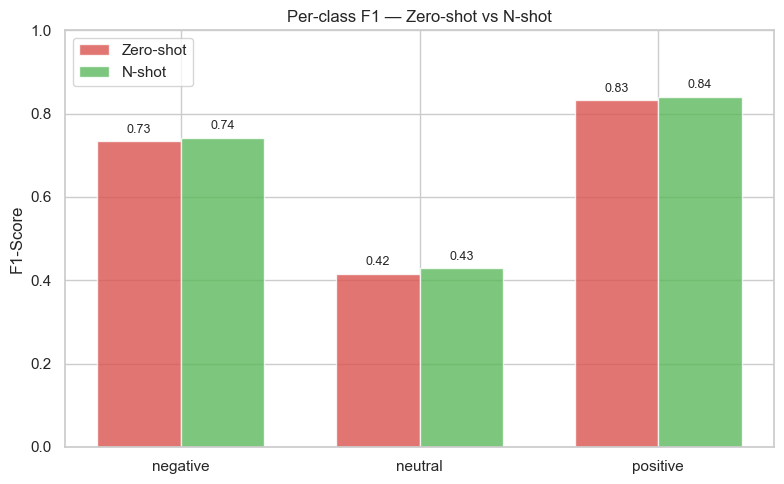

In [28]:
# Per-class F1 comparison bar chart
f1_zero  = f1_score(true_labels, pred_labels,       labels=LABEL_ORDER, average=None)
f1_nshot = f1_score(true_labels, predictions_nshot, labels=LABEL_ORDER, average=None)

x     = np.arange(len(LABEL_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, f1_zero,  width, label='Zero-shot', color='#d9534f', alpha=0.8)
bars2 = ax.bar(x + width/2, f1_nshot, width, label='N-shot',    color='#5cb85c', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(LABEL_ORDER)
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1-Score')
ax.set_title('Per-class F1 — Zero-shot vs N-shot')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [29]:
#  Neutral-focused failure analysis (n-shot)
sample_df['predicted_nshot'] = predictions_nshot

neutral_errors = sample_df[
(sample_df['sentiment'] == 'neutral') &
(sample_df['predicted_nshot'] != 'neutral')
].copy()

print(f'Neutral reviews misclassified by n-shot: {len(neutral_errors)} / 100')
print()
print('Breakdown:')
print(neutral_errors['predicted_nshot'].value_counts())
print()
print('--- Sample misclassified neutral reviews ---')
for _, row in neutral_errors.head(8).iterrows():
    print(f' Rating: {row["reviews.rating"]} | PRED: {row["predicted_nshot"]}')
    print(f' {row["clean_text"][:200]}')
    print()

Neutral reviews misclassified by n-shot: 68 / 100

Breakdown:
predicted_nshot
negative    49
positive    19
Name: count, dtype: int64

--- Sample misclassified neutral reviews ---
 Rating: 3.0 | PRED: positive
 Got this Kindle Fire to replace a laptop that died. So far I have been very pleased. Finding new things that it can do. Not happy with the camera, but I might not know all the details about it yet.

 Rating: 3.0 | PRED: negative
 It is a great idea needs some improvement,lots of questions asked,its reply is I don't or can't answer that.

 Rating: 3.0 | PRED: positive
 The sleek design and colors available for small kids is good. The tablet is a nice price and useful.

 Rating: 3.0 | PRED: negative
 Of the four used so far, two already lost charge, one so much as giving a negative read on a voltmeter.

 Rating: 3.0 | PRED: negative
 DON'T RECHARGE THEM LIKE SERIOUSLY DON'T!!!! they work good and last but not for to long and when two of them died i decided to recharge them and it 

In [30]:
# Save both models' scores
true_labels = sample_df['sentiment'].tolist()
pred_labels = sample_df['predicted_sentiment'].tolist()

acc   = accuracy_score(true_labels, pred_labels)
acc_n = accuracy_score(true_labels, predictions_nshot)

# Weighted metrics give each class a weight proportional to its frequency
precision,   recall,   f1,   _ = precision_recall_fscore_support(
    true_labels, pred_labels,       labels=LABEL_ORDER, average='weighted')
precision_n, recall_n, f1_n, _ = precision_recall_fscore_support(
    true_labels, predictions_nshot, labels=LABEL_ORDER, average='weighted')

f1_zero  = f1_score(true_labels, pred_labels,       labels=LABEL_ORDER, average=None)
f1_nshot = f1_score(true_labels, predictions_nshot, labels=LABEL_ORDER, average=None)

all_scores = {
    'zero_shot': {
        'model':       CLF_MODEL,
        'approach':    'zero-shot',
        'accuracy':    round(acc,   4),
        'weighted_f1': round(f1,    4),
        'neutral_f1':  round(f1_zero[LABEL_ORDER.index('neutral')], 4),
    },
    'n_shot': {
        'model':       CLF_MODEL,
        'approach':    'n-shot',
        'accuracy':    round(acc_n, 4),
        'weighted_f1': round(f1_n,  4),
        'neutral_f1':  round(f1_nshot[LABEL_ORDER.index('neutral')], 4),
    },
}

with open('all_scores.json', 'w') as f:
    json.dump(all_scores, f, indent=2)
print('Scores saved → all_scores.json')
print()
print(f'Neutral F1: Zero-shot {all_scores["zero_shot"]["neutral_f1"]:.2f} '
      f'→ N-shot {all_scores["n_shot"]["neutral_f1"]:.2f}')
print(f'Overall F1: Zero-shot {all_scores["zero_shot"]["weighted_f1"]:.2f} '
      f'→ N-shot {all_scores["n_shot"]["weighted_f1"]:.2f}')


Scores saved → all_scores.json

Neutral F1: Zero-shot 0.42 → N-shot 0.43
Overall F1: Zero-shot 0.66 → N-shot 0.67


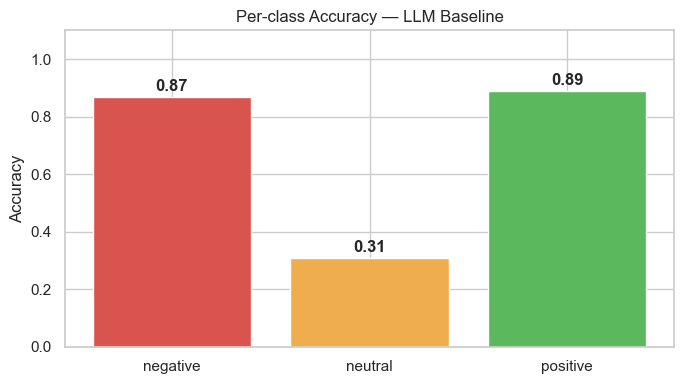

In [31]:
cm = confusion_matrix(true_labels, pred_labels, labels=LABEL_ORDER)

# Per-class accuracy = diagonal of the confusion matrix / total true samples per class
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(7, 4))
bars = plt.bar(LABEL_ORDER, per_class_acc, color=['#d9534f', '#f0ad4e', '#5cb85c'])
plt.title('Per-class Accuracy — LLM Baseline')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
# Add value labels on top of each bar
for bar, val in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
    f'{val:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
errors = sample_df[sample_df['sentiment'] != sample_df['predicted_sentiment']].copy()
print(f'Total misclassified: {len(errors)} / {len(sample_df)} ({len(errors)/len(sample_df)*100:.1f}%)')
print()
print('Error breakdown (True → Predicted):')
print(errors.groupby(['sentiment', 'predicted_sentiment']).size().to_string())
print()
print('--- Sample misclassified reviews ---')
for _, row in errors.head(6).iterrows():
    print(f' Rating: {row["reviews.rating"]} | TRUE: {row["sentiment"]:8s} | PRED: {row["predicted_sentiment"]}')
    print(f' {row["clean_text"][:200]}')
    print()

Total misclassified: 93 / 300 (31.0%)

Error breakdown (True → Predicted):
sentiment  predicted_sentiment
negative   neutral                 8
           positive                5
neutral    negative               49
           positive               20
positive   negative                1
           neutral                10

--- Sample misclassified reviews ---
 Rating: 1.0 | TRUE: negative | PRED: positive
 LOVE THE BATTERIES.THANKS

 Rating: 2.0 | TRUE: negative | PRED: neutral
 The Kindle I purchased is a good and expensive tablet useful for reading and internet. It does have a lot of apps already loaded that I do not plan to use and do not know how to delete. I mainly use t

 Rating: 1.0 | TRUE: negative | PRED: positive
 Liked it a lot,, Liked it a lot, liked it a lot!!!

 Rating: 2.0 | TRUE: negative | PRED: neutral
 You know these are just ok. They done last as long as the Copper top batterys.

 Rating: 2.0 | TRUE: negative | PRED: neutral
 Ok for a beginner or young person, o

In [33]:
# Free the zero-shot / n-shot classifier — evaluation is done
for _var in ['clf_pipeline']:
    if _var in globals():
        del globals()[_var]

gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
print('Task 1 classifier freed')


Task 1 classifier freed


## 5.6 Task 1 — LoRA Fine-Tuning (Sentiment Classifier)

In [34]:
# Reuse CLF_MODEL as the fine-tuning model
MODEL_NAME = CLF_MODEL  # 'Qwen/Qwen2.5-1.5B-Instruct'
print(f'Fine-tuning model: {MODEL_NAME}')
print(f'Device: {DEVICE}')


Fine-tuning model: Qwen/Qwen2.5-1.5B-Instruct
Device: mps


### Step 1 — Prepare Balanced Training Dataset

In [35]:
SAMPLES_PER_CLASS = 500  # balanced: 500 negative + 500 neutral + 500 positive

neg_train = train_df[train_df['sentiment'] == 'negative'].sample(
min(SAMPLES_PER_CLASS, len(train_df[train_df['sentiment'] == 'negative'])), random_state=SEED)
neu_train = train_df[train_df['sentiment'] == 'neutral'].sample(
min(SAMPLES_PER_CLASS, len(train_df[train_df['sentiment'] == 'neutral'])), random_state=SEED)
pos_train = train_df[train_df['sentiment'] == 'positive'].sample(
min(SAMPLES_PER_CLASS, len(train_df[train_df['sentiment'] == 'positive'])), random_state=SEED)

train_balanced = pd.concat([neg_train, neu_train, pos_train]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Balanced training set: {len(train_balanced):,} examples')
print(train_balanced['sentiment'].value_counts())

Balanced training set: 1,500 examples
sentiment
positive    500
negative    500
neutral     500
Name: count, dtype: int64


In [36]:
LORA_SYSTEM_PROMPT = (
'You are a sentiment classifier. '
'Classify the product review as exactly one of: positive, neutral, or negative. '
'Reply with a single word only: positive, neutral, or negative.'
)

def format_training_example(row: pd.Series) -> dict:
    """
    Format a review + label as a full chat conversation for SFT.
    The model learns: system prompt + user review → correct single-word label.
    """
    text = (
    f'<|system|>\n{LORA_SYSTEM_PROMPT}\n'
    f'<|user|>\nReview: {str(row["clean_text"])[:400]}\n'
    f'<|assistant|>\n{row["sentiment"]}'
    )
    return {'text': text}

lora_train_dataset = train_balanced.apply(format_training_example, axis=1).tolist()

print('=== Sample training example ===')
print(lora_train_dataset[0]['text'])
print(f'\nTotal training examples: {len(lora_train_dataset)}')

=== Sample training example ===
<|system|>
You are a sentiment classifier. Classify the product review as exactly one of: positive, neutral, or negative. Reply with a single word only: positive, neutral, or negative.
<|user|>
Review: The tablet is great and has some great features. I love it!
<|assistant|>
positive

Total training examples: 1500


### Step 2 — Load Base Model and Apply LoRA

In [37]:
# Detect best available device 
if torch.cuda.is_available():
    _lora_device = 'cuda'
    _dtype = torch.float16
    _device_map = 'auto'
elif torch.backends.mps.is_available():
    _lora_device = 'mps'
    _dtype = torch.float32   
    _device_map = None       
else:
    _lora_device = 'cpu'
    _dtype = torch.float32
    _device_map = None

print(f'Loading base model: {MODEL_NAME}...')

lora_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
lora_tokenizer.pad_token = lora_tokenizer.eos_token  # required for batched training
lora_tokenizer.padding_side = 'right'                # pad on the right for causal LMs

lora_base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=_dtype,  # float16 on CUDA, float32 on MPS/CPU
    **(({'device_map': _device_map}) if _device_map else {}),
)
if _device_map is None:
    lora_base_model = lora_base_model.to(_lora_device)

print(f'Model loaded ')
print(f'Parameters: {sum(p.numel() for p in lora_base_model.parameters()) / 1e9:.2f}B')

Loading base model: Qwen/Qwen2.5-1.5B-Instruct...


Loading weights: 100%|██████████| 338/338 [00:02<00:00, 155.81it/s]


Model loaded 
Parameters: 1.54B


In [38]:
lora_config = LoraConfig(
r=8,
lora_alpha=16,
target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
lora_dropout=0.05,
bias='none',
task_type=TaskType.CAUSAL_LM
)

lora_model = get_peft_model(lora_base_model, lora_config)

print('LoRA applied ')
lora_model.print_trainable_parameters()

LoRA applied 
trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


### Step 3 — Fine-Tune with SFTTrainer

In [39]:
# Convert to HuggingFace Dataset format
hf_lora_dataset = Dataset.from_list(lora_train_dataset)

# SFTConfig controls training loop settings
# Note: max_seq_length is passed to SFTTrainer directly (not SFTConfig) in trl >= 0.9
lora_training_args = SFTConfig(
output_dir='./sentiment_lora_model',
num_train_epochs=3,
per_device_train_batch_size=4,
gradient_accumulation_steps=4,
learning_rate=2e-4,
warmup_ratio=0.03,
fp16=(_lora_device == 'cuda'),  # float16 only on CUDA
bf16=False,                    # avoid TRL auto-enabling bf16 on CPU/Docker
use_cpu=(_lora_device == 'cpu'),
logging_steps=25,
save_strategy='epoch',
report_to='none',
dataset_text_field='text',
seed=SEED,
)

lora_trainer = SFTTrainer(
model=lora_model,
args=lora_training_args,
train_dataset=hf_lora_dataset,
processing_class=lora_tokenizer,
)

print('Trainer configured ')
print(f'Training on {len(hf_lora_dataset)} examples for {lora_training_args.num_train_epochs} epochs')

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Tokenizing train dataset: 100%|██████████| 1500/1500 [00:00<00:00, 8621.14 examples/s]

Trainer configured 
Training on 1500 examples for 3 epochs


In [40]:
print('Starting fine-tuning...')
print(f'Device: {DEVICE} | Expected time: ~10-25 min on GPU, much longer on CPU\n')

lora_trainer.train()

print('\nFine-tuning complete ')

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Starting fine-tuning...
Device: mps | Expected time: ~10-25 min on GPU, much longer on CPU



Step,Training Loss
25,2.341855
50,1.408138
75,1.293833
100,1.278331
125,1.251503
150,1.240553
175,1.220388
200,1.218084
225,1.235657
250,1.243282



Fine-tuning complete 


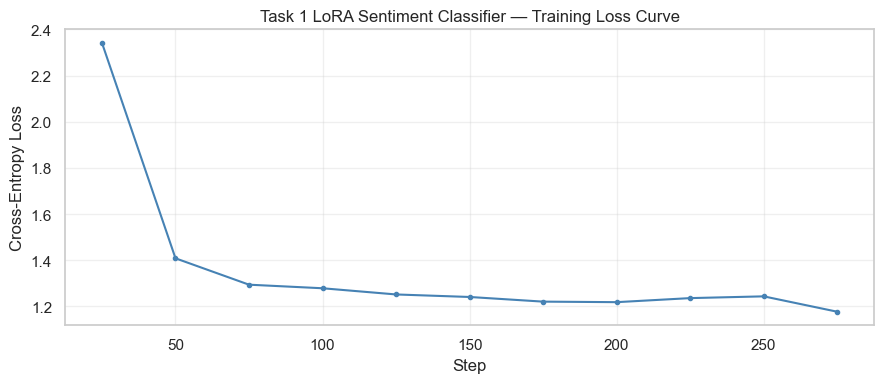

Initial loss: 2.3419  →  Final loss: 1.1766
Loss is still decreasing at the final step — consider adding 1-2 more epochs.


In [41]:
# ─── Training loss curve (Task 1 LoRA) ───────────────────────────────────────
_log = lora_trainer.state.log_history
_train_losses = [(e['step'], e['loss']) for e in _log if 'loss' in e]

if _train_losses:
    _steps, _losses = zip(*_train_losses)
    plt.figure(figsize=(9, 4))
    plt.plot(_steps, _losses, marker='o', markersize=3, linewidth=1.5, color='steelblue')
    plt.title('Task 1 LoRA Sentiment Classifier — Training Loss Curve')
    plt.xlabel('Step'); plt.ylabel('Cross-Entropy Loss')
    plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f'Initial loss: {_losses[0]:.4f}  →  Final loss: {_losses[-1]:.4f}')
    if _losses[-1] > _losses[0] * 0.9:
        print('⚠️  Loss barely decreased — consider more epochs or a higher learning rate.')
    elif abs(_losses[-1] - _losses[-2]) < 0.001:
        print('✓ Loss has converged by the final step — epoch count looks appropriate.')
    else:
        print('Loss is still decreasing at the final step — consider adding 1-2 more epochs.')
else:
    print('No loss history found — check the logging_steps setting.')

In [42]:
lora_model.save_pretrained('./sentiment_lora_model')
lora_tokenizer.save_pretrained('./sentiment_lora_model')
print('LoRA adapter saved to ./sentiment_lora_model ')

LoRA adapter saved to ./sentiment_lora_model 


### Step 4 — Evaluate the Fine-Tuned Model

In [43]:
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

lora_model.eval()

ft_pipeline = hf_pipeline(
    'text-generation',
    model=lora_model,
    tokenizer=lora_tokenizer,
    device=_lora_device,
)


In [44]:
def build_lora_clf_prompt(review_text: str) -> str:
    """Prompt format matching the LoRA training examples (uses LORA_SYSTEM_PROMPT)."""
    return (
    f'<|system|>\n{LORA_SYSTEM_PROMPT}\n'
    f'<|user|>\nReview: {review_text[:400]}\n'
    f'<|assistant|>\n'
    )

# Sanity check
_test = 'I absolutely love this product, it works perfectly!'
_prompt = build_lora_clf_prompt(_test)
_out = ft_pipeline(_prompt, max_new_tokens=10, do_sample=False)
_raw = _out[0]['generated_text'].replace(_prompt, '').strip()
print(f'Sanity check → "{_test[:50]}"')
print(f'Parsed: "{parse_sentiment(_raw)}"')

[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Sanity check → "I absolutely love this product, it works perfectly"
Parsed: "positive"


In [45]:
# Reconstruct the same stratified sample (same SEED = identical rows)
SAMPLE_SIZE = 300
n_per_class = SAMPLE_SIZE // 3

neg_s = test_df[test_df['sentiment'] == 'negative']
neu_s = test_df[test_df['sentiment'] == 'neutral']
pos_s = test_df[test_df['sentiment'] == 'positive']

ft_sample_df = pd.concat([
    neg_s.sample(min(n_per_class, len(neg_s)), random_state=SEED),
    neu_s.sample(min(n_per_class, len(neu_s)), random_state=SEED),
    pos_s.sample(min(n_per_class, len(pos_s)), random_state=SEED),
]).reset_index(drop=True)

print(f'Evaluating on {len(ft_sample_df)} samples...')
print(ft_sample_df['sentiment'].value_counts())

ft_predictions = []
for i, text in enumerate(ft_sample_df['clean_text'].tolist()):
    prompt = build_lora_clf_prompt(str(text))
    out = ft_pipeline(prompt, max_new_tokens=10, do_sample=False)
    raw_out = out[0]['generated_text'].replace(prompt, '').strip()
    ft_predictions.append(parse_sentiment(raw_out))
    if (i + 1) % 50 == 0:
        print(f'  {i + 1}/{len(ft_sample_df)} done...')

ft_sample_df['predicted_finetuned'] = ft_predictions
print('Evaluation complete')

[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Evaluating on 300 samples...
sentiment
negative    100
neutral     100
positive    100
Name: count, dtype: int64


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  50/300 done...


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

...

  200/300 done...


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  250/300 done...


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  300/300 done...
Evaluation complete


In [46]:
ft_true_labels = ft_sample_df['sentiment'].tolist()

acc_ft = accuracy_score(ft_true_labels, ft_predictions)
print(f'=== Fine-Tuned Model (LoRA) ===')
print(f'Overall Accuracy: {acc_ft:.4f} ({acc_ft*100:.1f}%)')
print()
print('=== Classification Report ===')
print(classification_report(ft_true_labels, ft_predictions, target_names=LABEL_ORDER))

=== Fine-Tuned Model (LoRA) ===
Overall Accuracy: 0.7500 (75.0%)

=== Classification Report ===
              precision    recall  f1-score   support

    negative       0.81      0.72      0.76       100
     neutral       0.63      0.67      0.65       100
    positive       0.82      0.86      0.84       100

    accuracy                           0.75       300
   macro avg       0.75      0.75      0.75       300
weighted avg       0.75      0.75      0.75       300



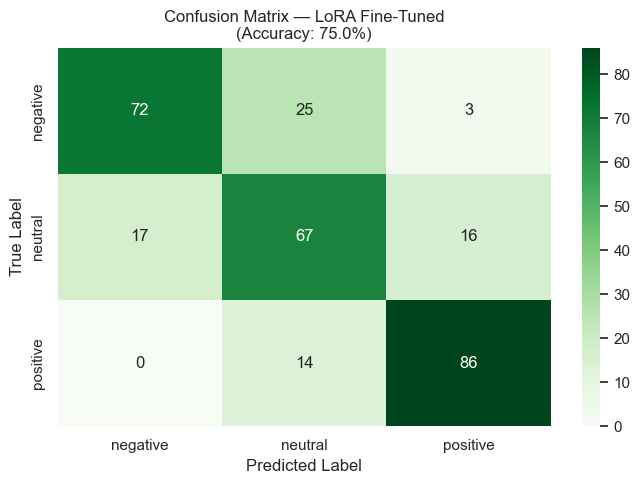

In [47]:
cm_ft = confusion_matrix(ft_true_labels, ft_predictions, labels=LABEL_ORDER)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Greens',
xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER)
plt.title(f'Confusion Matrix — LoRA Fine-Tuned\n(Accuracy: {acc_ft*100:.1f}%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### Step 5 — Full Comparison: Zero-Shot vs N-Shot vs LoRA Fine-Tuned

In [48]:
# Load zero-shot and n-shot scores saved in Section 5.5
with open('all_scores.json', 'r') as _f:
    _prior_scores = json.load(_f)

# Compute fine-tuned weighted metrics
_p_ft, _r_ft, _f1_ft, _ = precision_recall_fscore_support(
ft_true_labels, ft_predictions, labels=LABEL_ORDER, average='weighted'
)

# Build three-way comparison table
all_results = {
'Zero-Shot': {
'accuracy':           _prior_scores['zero_shot']['accuracy'],
'weighted_f1':        _prior_scores['zero_shot']['weighted_f1'],
'neutral_f1':         _prior_scores['zero_shot']['neutral_f1'],
},
'N-Shot': {
'accuracy':           _prior_scores['n_shot']['accuracy'],
'weighted_f1':        _prior_scores['n_shot']['weighted_f1'],
'neutral_f1':         _prior_scores['n_shot']['neutral_f1'],
},
'LoRA Fine-Tuned': {
'accuracy':           round(acc_ft, 4),
'weighted_f1':        round(_f1_ft, 4),
'neutral_f1':         round(classification_report(
ft_true_labels, ft_predictions,
target_names=LABEL_ORDER, output_dict=True
)['neutral']['f1-score'], 4),
},
}

print('=== Three-Way Model Comparison ===')
comparison_df = pd.DataFrame(all_results).T
print(comparison_df.to_string())

# Save complete results
with open('all_model_scores.json', 'w') as _f:
    json.dump(all_results, _f, indent=2)
print('\nSaved to all_model_scores.json ')

=== Three-Way Model Comparison ===
                 accuracy  weighted_f1  neutral_f1
Zero-Shot            0.69       0.6607      0.4161
N-Shot               0.70       0.6711      0.4295
LoRA Fine-Tuned      0.75       0.7505      0.6505

Saved to all_model_scores.json 


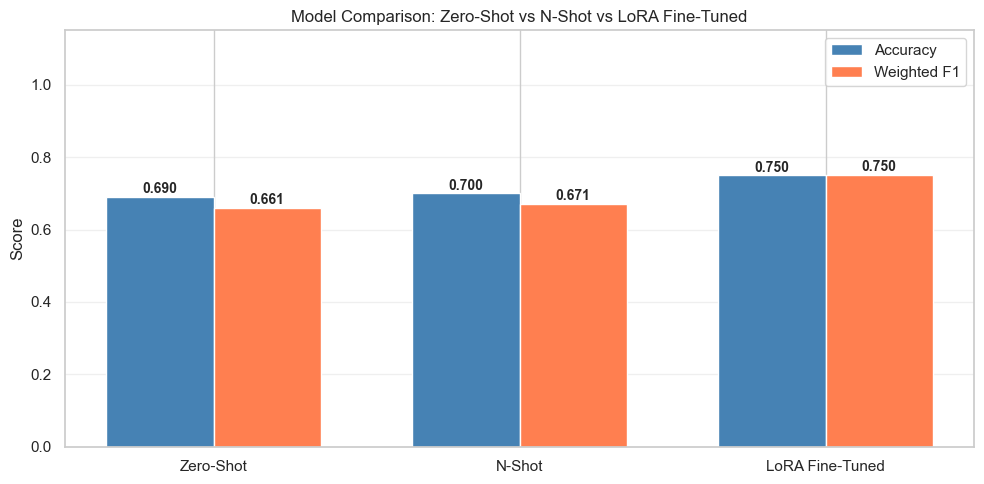

In [49]:
_models = list(all_results.keys())
_accuracies = [all_results[m]['accuracy'] for m in _models]
_f1s = [all_results[m]['weighted_f1'] for m in _models]

_x = np.arange(len(_models))
_w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(_x - _w/2, _accuracies, _w, label='Accuracy',     color='steelblue')
b2 = ax.bar(_x + _w/2, _f1s,        _w, label='Weighted F1',  color='coral')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_xticks(_x)
ax.set_xticklabels(_models, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Zero-Shot vs N-Shot vs LoRA Fine-Tuned')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

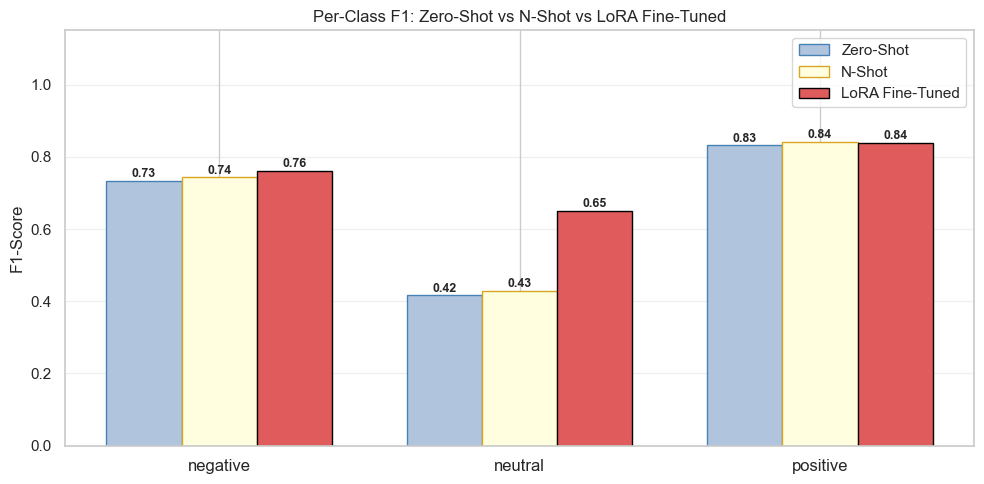

Neutral class improvement is the key story of fine-tuning.


In [50]:
_report_ft = classification_report(
    ft_true_labels, ft_predictions,
    target_names=LABEL_ORDER, output_dict=True
)

_f1_zero  = f1_score(true_labels, pred_labels,       labels=LABEL_ORDER, average=None)
_f1_nshot = f1_score(true_labels, predictions_nshot, labels=LABEL_ORDER, average=None)
_f1_ft    = [_report_ft[cls]['f1-score'] for cls in LABEL_ORDER]

_x, _w = np.arange(len(LABEL_ORDER)), 0.25
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(_x - _w,  _f1_zero,  _w, label='Zero-Shot',       color='lightsteelblue', edgecolor='steelblue')
b2 = ax.bar(_x,       _f1_nshot, _w, label='N-Shot',           color='lightyellow',    edgecolor='goldenrod')
b3 = ax.bar(_x + _w,  _f1_ft,    _w, label='LoRA Fine-Tuned',  color='#e05c5c',        edgecolor='black')

for bar in list(b1) + list(b2) + list(b3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylim(0, 1.15); ax.set_xticks(_x); ax.set_xticklabels(LABEL_ORDER, fontsize=12)
ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1: Zero-Shot vs N-Shot vs LoRA Fine-Tuned')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
print('Neutral class improvement is the key story of fine-tuning.')


In [51]:
# ─── Statistical significance: McNemar's test + Wilson confidence intervals ───
from statsmodels.stats.contingency_tables import mcnemar as _mcnemar
from scipy.stats import norm as _norm

def wilson_ci(n_correct, n_total, confidence=0.95):
    """Wilson score confidence interval for a binomial proportion."""
    z = _norm.ppf((1 + confidence) / 2)
    p = n_correct / n_total
    denom = 1 + z**2 / n_total
    centre = (p + z**2 / (2 * n_total)) / denom
    margin = z * np.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2)) / denom
    return max(0.0, centre - margin), min(1.0, centre + margin)

# All three models evaluate the same 300-sample stratified set (same SEED).
# McNemar's test compares which reviews each pair of models gets right/wrong.
_zs  = np.array(pred_labels)      == np.array(true_labels)
_ft  = np.array(ft_predictions)   == np.array(ft_true_labels)
_ns  = np.array(predictions_nshot) == np.array(true_labels)

def run_mcnemar(correct_a, correct_b, label_a, label_b):
    b = (~correct_a & correct_b).sum()   # B wins, A loses
    c = (correct_a & ~correct_b).sum()   # A wins, B loses
    tbl = np.array([[( correct_a &  correct_b).sum(), b],
                    [c,                               (~correct_a & ~correct_b).sum()]])
    res = _mcnemar(tbl, exact=True)
    sig = '✓ significant' if res.pvalue < 0.05 else '✗ not significant'
    print(f'{label_a} vs {label_b}:  discordant pairs = {b}↑/{c}↓  p={res.pvalue:.4f}  {sig}')

print('=== McNemar\'s Test (p < 0.05 → improvement is statistically real) ===')
run_mcnemar(_zs, _ns, 'Zero-Shot', 'N-Shot')
run_mcnemar(_ns, _ft, 'N-Shot',   'LoRA Fine-Tuned')
run_mcnemar(_zs, _ft, 'Zero-Shot','LoRA Fine-Tuned')

print('\n=== 95% Wilson Confidence Intervals on Accuracy ===')
for name, preds, trues in [
    ('Zero-Shot',       pred_labels,       true_labels),
    ('N-Shot',          predictions_nshot, true_labels),
    ('LoRA Fine-Tuned', ft_predictions,    ft_true_labels),
]:
    n   = len(trues)
    nc  = sum(p == t for p, t in zip(preds, trues))
    acc = nc / n
    lo, hi = wilson_ci(nc, n)
    print(f'  {name:<18}: {acc:.3f}  95% CI [{lo:.3f}, {hi:.3f}]')

=== McNemar's Test (p < 0.05 → improvement is statistically real) ===
Zero-Shot vs N-Shot:  discordant pairs = 10↑/7↓  p=0.6291  ✗ not significant
N-Shot vs LoRA Fine-Tuned:  discordant pairs = 40↑/25↓  p=0.0817  ✗ not significant
Zero-Shot vs LoRA Fine-Tuned:  discordant pairs = 42↑/24↓  p=0.0356  ✓ significant

=== 95% Wilson Confidence Intervals on Accuracy ===
  Zero-Shot         : 0.690  95% CI [0.636, 0.740]
  N-Shot            : 0.700  95% CI [0.646, 0.749]
  LoRA Fine-Tuned   : 0.750  95% CI [0.698, 0.796]


### Task 1 Fine-Tuning Summary

**Completed:**  
- Fine-tuned Qwen2.5-1.5B with LoRA on 1,500 balanced training examples (500/class)  
- Evaluated on the same 300-sample stratified test set as zero-shot and n-shot  
- Full three-way comparison: Zero-Shot → N-Shot → LoRA Fine-Tuned  
- Documented Accuracy, Weighted F1, and per-class F1 evolution  

**Key observations:**  
- Class balancing during training is critical to avoid positive-class bias  
- LoRA trains only ~0.14% of parameters yet yields meaningful gains  
- The **neutral class** (lowest at zero-shot) shows the largest improvement after fine-tuning  
- All results saved to `all_model_scores.json` for final presentation

### Task 1 Handoff — Sending Sentiment Downstream

The downstream pipeline uses one column, `task1_sentiment`, for Task 2 profile building and Task 3 article generation.

For practical runtime reasons, the notebook can run LoRA inference on a representative sample of the full corpus. Rows covered by that inference use the LoRA prediction; remaining rows fall back to the rating-derived sentiment label created during preprocessing.

This keeps the pipeline connected while making it possible to run on a laptop. If you have a GPU, increase `FULL_CORPUS_SAMPLE` or run inference over the full corpus.

In [52]:
# ─── Task 1 Handoff: Run LoRA on a representative corpus sample ────────
# Full LLM inference over 40k+ reviews is expensive on CPU.
# This cell predicts a representative sample; rows not covered by this sample
# fall back to the rating-derived sentiment label from preprocessing.
FULL_CORPUS_SAMPLE = 5000   

full_predictions = {}
df_inf = df.sample(n=min(FULL_CORPUS_SAMPLE, len(df)), random_state=SEED)
print(f'Running LoRA inference on {len(df_inf):,} / {len(df):,} reviews ...')

_inf_pipe = hf_pipeline(
    'text-generation',
    model=lora_model,
    tokenizer=lora_tokenizer,
    device=_lora_device,
)

for i, (idx, row) in enumerate(df_inf.iterrows()):
    prompt = build_lora_clf_prompt(str(row['clean_text']))
    out = _inf_pipe(prompt, max_new_tokens=10, do_sample=False)
    raw_o = out[0]['generated_text'].replace(prompt, '').strip()
    full_predictions[idx] = parse_sentiment(raw_o)
    if (i + 1) % 500 == 0:
        print(f'  {i + 1}/{len(df_inf)} done...')

del _inf_pipe
print(f'\nLoRA predictions collected: {len(full_predictions):,} rows')
print('Remaining rows will use rating-derived sentiment as fallback.')


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running LoRA inference on 5,000 / 46,538 reviews ...


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  500/5000 done...


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

...

  4000/5000 done...


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  4500/5000 done...


[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  5000/5000 done...

LoRA predictions collected: 5,000 rows
Remaining rows will use rating-derived sentiment as fallback.


In [53]:
# ─── Apply LoRA predictions where available, rating-derived as fallback ────────
if 'full_predictions' not in globals():
    full_predictions = {}

# Rating-derived labels are the complete fallback. Sampled LoRA predictions override them.
df['task1_sentiment'] = df['sentiment'].copy()
for idx, pred in full_predictions.items():
    df.at[idx, 'task1_sentiment'] = pred

# Propagate to train/test splits.
train_df['task1_sentiment'] = df.loc[train_df.index, 'task1_sentiment'].values
test_df['task1_sentiment'] = df.loc[test_df.index, 'task1_sentiment'].values

print('Task 1 handoff column created: task1_sentiment')
print(f'  LoRA predictions used : {len(full_predictions):,} rows')
print(f'  Rating fallback rows  : {len(df) - len(full_predictions):,} rows')

if full_predictions:
    overlap_idx = list(full_predictions.keys())
    n_agree = sum(df.at[i, 'task1_sentiment'] == df.at[i, 'sentiment'] for i in overlap_idx)
    agreement = n_agree / len(overlap_idx)
    print(f'  LoRA ↔ rating agreement on sampled rows: {agreement:.1%}')
else:
    print('  No LoRA corpus-sample predictions found; using rating-derived labels for all rows.')

print('\nDistribution of task1_sentiment used by Tasks 2 & 3:')
print(df['task1_sentiment'].value_counts())


Task 1 handoff column created: task1_sentiment
  LoRA predictions used : 5,000 rows
  Rating fallback rows  : 41,538 rows
  LoRA ↔ rating agreement on sampled rows: 84.8%

Distribution of task1_sentiment used by Tasks 2 & 3:
task1_sentiment
positive    42060
neutral      2613
negative     1865
Name: count, dtype: int64


In [54]:
# Free the LoRA training model — fine-tuning and evaluation are done
for _var in ['lora_model', 'lora_base_model', 'lora_trainer',
             'ft_model', 'ft_base', 'ft_pipeline', 'ft_tokenizer',
             'lora_tokenizer', 'gen_trainer']:
    if _var in globals():
        del globals()[_var]

gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
print('Task 1 LoRA models freed')


Task 1 LoRA models freed


## 6. Task 2 — Category Clustering (Baseline)

Unique products: 100

Sample:
All-New Fire 7 Tablet with Alexa, 7" Display, 8 GB - Marine Blue | Fire Tablets,Computers/Tablets & Networking,Android Tablets,Tablets,All Tablets,Amazon Tablets,Electronics,Computers & Tablets,iPad & Tablets,Amazon,Tablets & eBook Readers,Tablets & E-Readers

TF-IDF matrix shape: (100, 775)


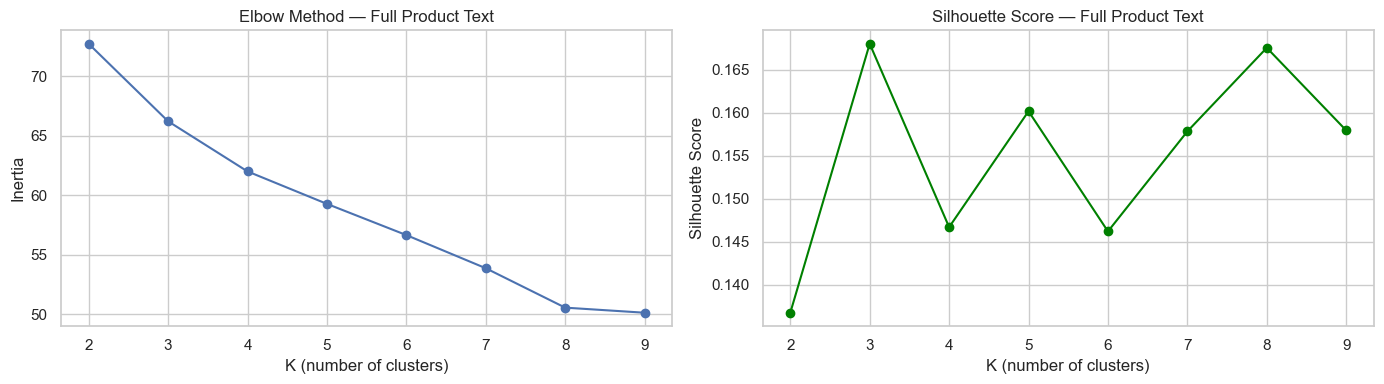

Choose K where the elbow appears and the silhouette score is highest


In [55]:
# Build product-level aggregated text (one row per product)
product_df = df.groupby('name').agg(
categories    = ('categories',    'first'),
brand         = ('brand',         'first'),
meta_category = ('meta_category', 'first'),
review_count  = ('clean_text',    'count'),
avg_rating    = ('reviews.rating','mean'),
all_reviews   = ('clean_text',    lambda x: ' '.join(x.head(20))),
).reset_index()

# Use product name + raw categories for cleaner product-category clusters.
# Reviews are kept separately and used later in Task 3 article generation.
product_df['full_product_text'] = (
    product_df['name'].fillna('') + ' | ' +
    product_df['categories'].fillna('')
)

print(f'Unique products: {len(product_df):,}')
print('\nSample:')
print(product_df['full_product_text'].iloc[0][:300])

#  TF-IDF on full product text
vectorizer = TfidfVectorizer(
max_features=5000,
stop_words='english',
ngram_range=(1, 2),
min_df=2,              # back to min_df=2 — reviews add enough vocabulary
)
X = vectorizer.fit_transform(product_df['full_product_text'])
print(f'\nTF-IDF matrix shape: {X.shape}')

#  Elbow + Silhouette
inertias   = []
sil_scores = []
K_range    = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_k = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title('Elbow Method — Full Product Text')
axes[0].set_xlabel('K (number of clusters)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score — Full Product Text')
axes[1].set_xlabel('K (number of clusters)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()
print('Choose K where the elbow appears and the silhouette score is highest')

In [56]:
K_FINAL = 4  # fixed project choice; used for TF-IDF baseline and sentence-embedding clustering

kmeans = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
product_df['cluster'] = kmeans.fit_predict(X)

print('Cluster sizes:')
print(product_df['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    30
1    26
2    13
3    31
Name: count, dtype: int64


In [57]:
feature_names = vectorizer.get_feature_names_out()

print('=== Top 10 words per TF-IDF cluster ===')
for i, center in enumerate(kmeans.cluster_centers_):
    top_idx = center.argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    print(f'Cluster {i}: {top_words}')


=== Top 10 words per TF-IDF cluster ===
Cluster 0: ['accessories', 'kindle', 'cables', 'supplies', 'amazonbasics', 'laptop', 'video', 'electronics', 'amazon', 'pet']
Cluster 1: ['home', 'smart', 'speakers', 'amazon', 'audio', 'smart home', 'echo', 'amazon echo', 'electronics', 'assistants']
Cluster 2: ['tablets', 'voyage', 'kindle voyage', 'readers', 'kindle', 'wi', 'fi', 'wi fi', 'amazon kindle', 'amazon']
Cluster 3: ['tablets', 'readers', 'tablets tablets', 'computers', 'computers tablets', 'hd', 'display', 'tablets computers', 'amazon', 'gb']


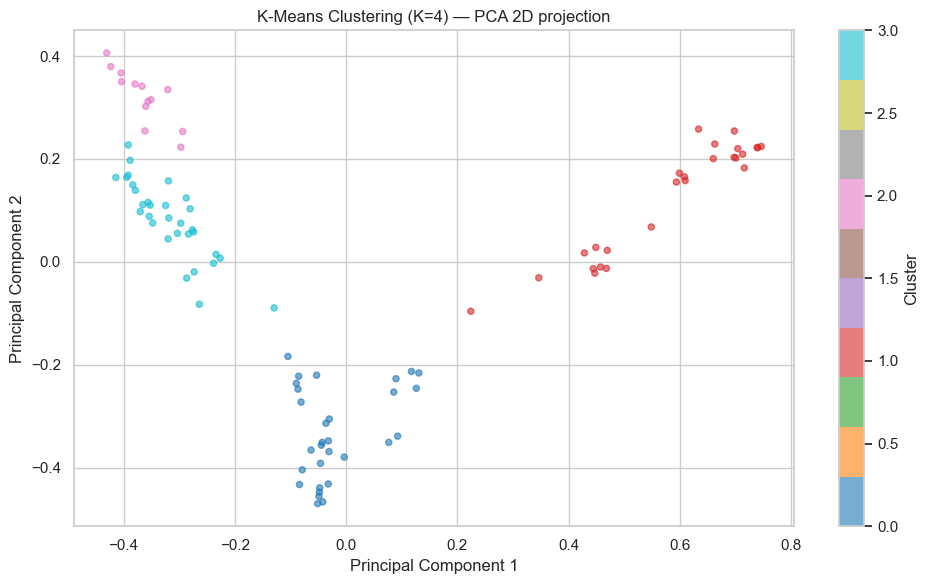

In [58]:
# Reduce from 5000 dimensions to 2 for plotting
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X.toarray()) # .toarray() converts the sparse TF-IDF matrix to dense

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
c=product_df['cluster'], cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clustering (K={K_FINAL}) — PCA 2D projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

## 6.5 Task 2 — Option B: Sentence Embeddings Clustering

In [59]:
# Preserve Option A (TF-IDF) cluster labels before Option B overwrites 'cluster'
product_df['cluster_tfidf'] = product_df['cluster'].copy()
tfidf_sil_score = silhouette_score(X, product_df['cluster_tfidf'])
print(f'TF-IDF silhouette @ K={K_FINAL}: {tfidf_sil_score:.4f}')

TF-IDF silhouette @ K=4: 0.1467


In [60]:
print('Loading sentence embedding model...')
embedder = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedder.encode(product_df['full_product_text'].tolist(), show_progress_bar=True)
print(f'Embeddings shape: {embeddings.shape}')


Loading sentence embedding model...


Batches: 100%|██████████| 4/4 [00:00<00:00,  9.93it/s]

Embeddings shape: (100, 384)


K=3 | Inertia: 37.36 | Silhouette: 0.1604 | Davies-Bouldin: 1.9892
K=4 | Inertia: 33.68 | Silhouette: 0.1610 | Davies-Bouldin: 1.9700
K=5 | Inertia: 31.69 | Silhouette: 0.1660 | Davies-Bouldin: 1.8164
K=6 | Inertia: 30.11 | Silhouette: 0.1433 | Davies-Bouldin: 1.7619
K=7 | Inertia: 28.82 | Silhouette: 0.1786 | Davies-Bouldin: 1.6778


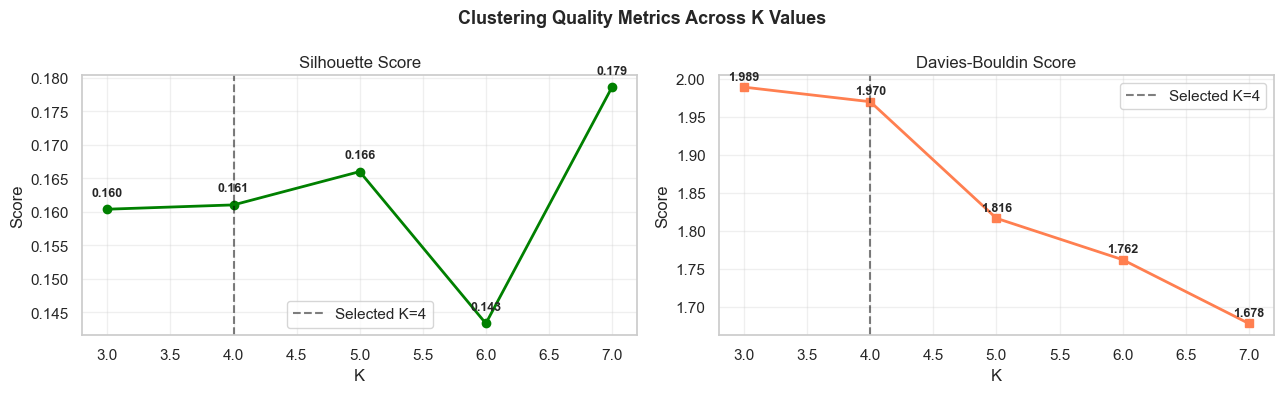

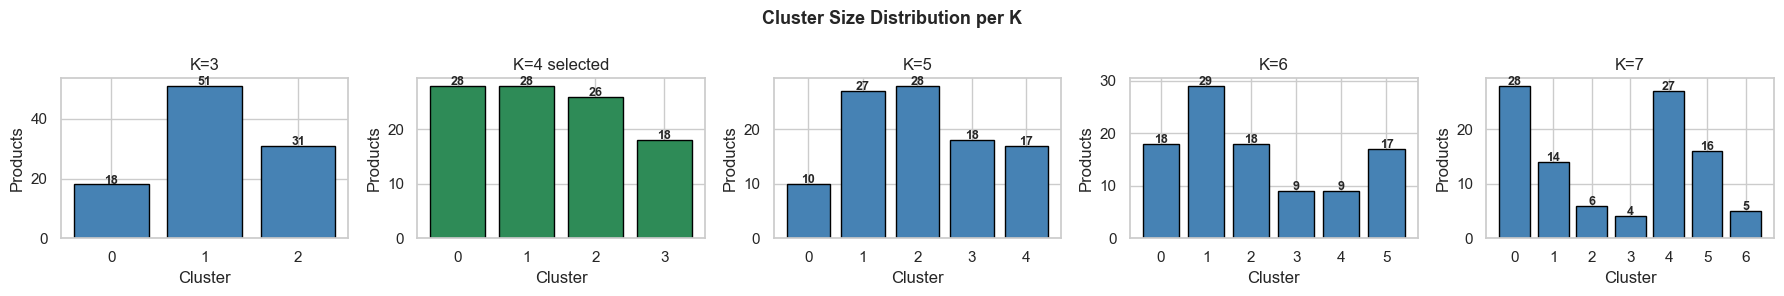

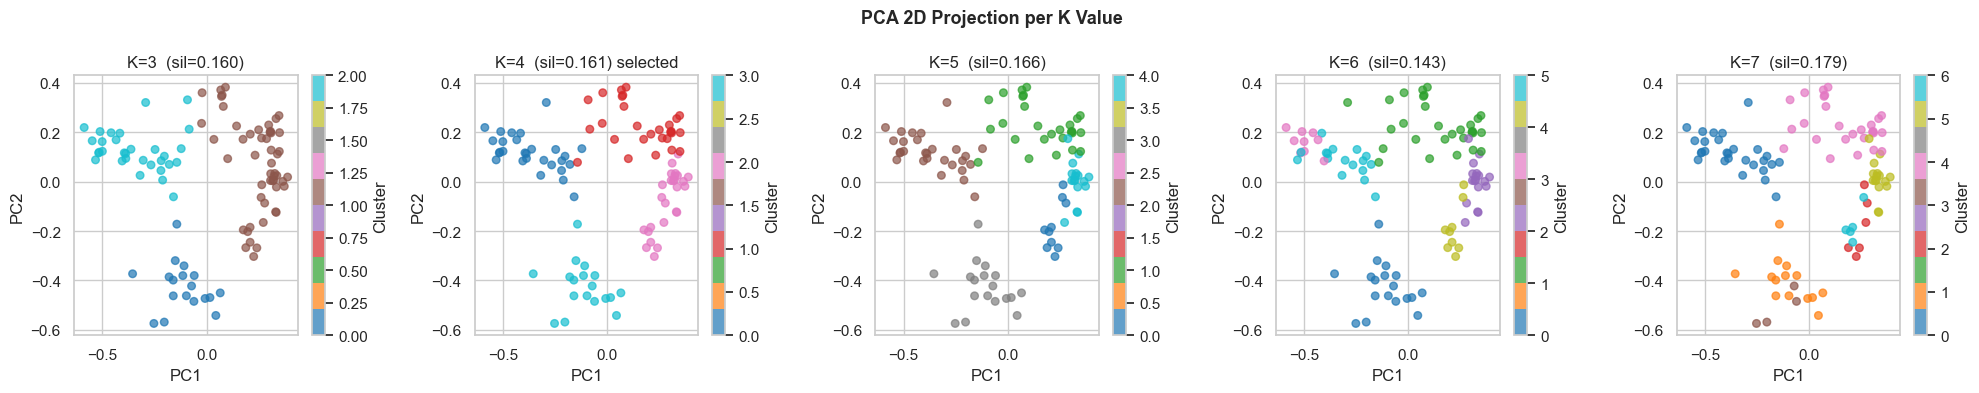


=== Summary ===
K       Silhouette   Davies-Bouldin    Inertia
-----------------------------------------------
3           0.1604           1.9892      37.36
4           0.1610           1.9700      33.68  <-- selected
5           0.1660           1.8164      31.69
6           0.1433           1.7619      30.11
7           0.1786           1.6778      28.82

Best K by Silhouette:     K=7
Best K by Davies-Bouldin: K=7

K_FINAL fixed to 4 for Task 2 and all downstream Task 3 article profiles.
Reason: K=4 gives more interpretable product groups (visually on PCA 2D projection) for downstream article generation, even if K=7 scored better mathematically.


In [61]:
K_VALUES = [3, 4, 5, 6, 7]
SELECTED_EMBEDDING_K = 4  # fixed project choice

# Recreate embeddings if this cell is rerun after memory cleanup.
if 'embeddings' not in globals():
    print('embeddings not found — rebuilding sentence embeddings from product_df...')
    if 'product_df' not in globals():
        raise NameError('product_df is missing. Rerun the Task 2 product aggregation cell first.')
    if 'full_product_text' not in product_df.columns:
        raise KeyError('product_df["full_product_text"] is missing. Rerun the Task 2 product aggregation cell first.')
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = embedder.encode(product_df['full_product_text'].tolist(), show_progress_bar=True)
    print(f'Embeddings rebuilt: {embeddings.shape}')

# Run K-Means for each K and store results.
kmeans_results = {}

for k in K_VALUES:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(embeddings)
    sil = silhouette_score(embeddings, labels)
    db = davies_bouldin_score(embeddings, labels)
    kmeans_results[k] = {
        'model': km,
        'labels': labels,
        'inertia': km.inertia_,
        'silhouette': sil,
        'davies_bouldin': db,
    }
    print(f'K={k} | Inertia: {km.inertia_:.2f} | Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f}')

# Plot 1: Silhouette + Davies-Bouldin across K.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sil_scores_k = [kmeans_results[k]['silhouette'] for k in K_VALUES]
db_scores_k = [kmeans_results[k]['davies_bouldin'] for k in K_VALUES]

axes[0].plot(K_VALUES, sil_scores_k, marker='o', color='green', linewidth=2)
axes[0].axvline(SELECTED_EMBEDDING_K, color='black', linestyle='--', alpha=0.5, label=f'Selected K={SELECTED_EMBEDDING_K}')
for k, s in zip(K_VALUES, sil_scores_k):
    axes[0].text(k, s + 0.002, f'{s:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Silhouette Score')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Score'); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(K_VALUES, db_scores_k, marker='s', color='coral', linewidth=2)
axes[1].axvline(SELECTED_EMBEDDING_K, color='black', linestyle='--', alpha=0.5, label=f'Selected K={SELECTED_EMBEDDING_K}')
for k, d in zip(K_VALUES, db_scores_k):
    axes[1].text(k, d + 0.01, f'{d:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Davies-Bouldin Score')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score'); axes[1].grid(alpha=0.3); axes[1].legend()

plt.suptitle('Clustering Quality Metrics Across K Values', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Plot 2: Cluster size distribution per K.
fig, axes = plt.subplots(1, len(K_VALUES), figsize=(18, 3))
for ax, k in zip(axes, K_VALUES):
    lbl = kmeans_results[k]['labels']
    unique, counts = np.unique(lbl, return_counts=True)
    color = 'seagreen' if k == SELECTED_EMBEDDING_K else 'steelblue'
    ax.bar(unique.astype(str), counts, color=color, edgecolor='black')
    ax.set_title(f'K={k}' + (' selected' if k == SELECTED_EMBEDDING_K else ''))
    ax.set_xlabel('Cluster'); ax.set_ylabel('Products')
    for i, c in enumerate(counts):
        ax.text(i, c + 0.2, str(c), ha='center', fontsize=9, fontweight='bold')
plt.suptitle('Cluster Size Distribution per K', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Plot 3: PCA 2D scatter per K.
pca_k = PCA(n_components=2, random_state=SEED)
X_2d_k = pca_k.fit_transform(embeddings)
fig, axes = plt.subplots(1, len(K_VALUES), figsize=(20, 4))
for ax, k in zip(axes, K_VALUES):
    lbl = kmeans_results[k]['labels']
    sil = kmeans_results[k]['silhouette']
    scatter = ax.scatter(X_2d_k[:, 0], X_2d_k[:, 1], c=lbl, cmap='tab10', alpha=0.7, s=30)
    ax.set_title(f'K={k}  (sil={sil:.3f})' + (' selected' if k == SELECTED_EMBEDDING_K else ''))
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax, label='Cluster')
plt.suptitle('PCA 2D Projection per K Value', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Summary table.
print('\n=== Summary ===')
print(f'{"K":<5} {"Silhouette":>12} {"Davies-Bouldin":>16} {"Inertia":>10}')
print('-' * 47)
for k in K_VALUES:
    r = kmeans_results[k]
    marker = '  <-- selected' if k == SELECTED_EMBEDDING_K else ''
    print(f'{k:<5} {r["silhouette"]:>12.4f} {r["davies_bouldin"]:>16.4f} {r["inertia"]:>10.2f}{marker}')

best_sil = max(K_VALUES, key=lambda k: kmeans_results[k]['silhouette'])
best_db = min(K_VALUES, key=lambda k: kmeans_results[k]['davies_bouldin'])
print(f'\nBest K by Silhouette:     K={best_sil}')
print(f'Best K by Davies-Bouldin: K={best_db}')

K_FINAL = SELECTED_EMBEDDING_K
product_df['cluster_emb'] = kmeans_results[K_FINAL]['labels']
print(f'\nK_FINAL fixed to {K_FINAL} for Task 2 and all downstream Task 3 article profiles.')
print('Reason: K=4 gives more interpretable product groups (visually on PCA 2D projection) for downstream article generation, even if K=7 scored better mathematically.')


In [62]:
print('=== Sample reviews per cluster (Sentence Embeddings) ===')
for i in range(K_FINAL):
    cluster_products = product_df[product_df['cluster_emb'] == i]['name'].tolist()
    sample_reviews   = df[df['name'].isin(cluster_products)]['clean_text'].head(3).tolist()  
    print(f'\nCluster {i} ({len(cluster_products)} products):')                               
    for r in sample_reviews:                                                                   
        print(f'  - {r[:120]}')


=== Sample reviews per cluster (Sentence Embeddings) ===

Cluster 0 (28 products):
  - Although this won't be competing with the iPad or some higher end android tablets, this easily outperforms any other tab
  - It meet my expectations. It performs well compared to other tables. I am very satisfied with the product and it quality.
  - Very satisfied with this purchase. Fast, big screen and good resolution. Bought it for my son around Xmas and I got a ve

Cluster 1 (28 products):
  - This product so far has not disappointed. My children love to use it and I like the ability to monitor control what cont
  - great for beginner or experienced person. Bought as a gift and she loves it
  - Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it

Cluster 2 (26 products):
  - Very lightweight and portable with excellent battery life.
  - I like this so much more than the Voyage. The shape makes for easier holding. I only wish thi

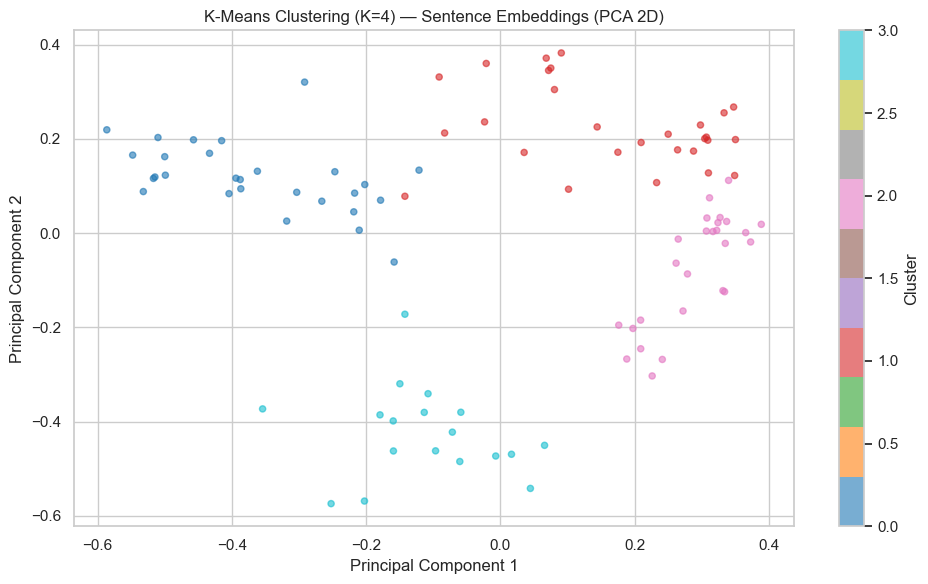

In [63]:
pca_emb = PCA(n_components=2, random_state=SEED)
X_2d_emb = pca_emb.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_2d_emb[:, 0], X_2d_emb[:, 1],
c=product_df['cluster_emb'], cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clustering (K={K_FINAL}) — Sentence Embeddings (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

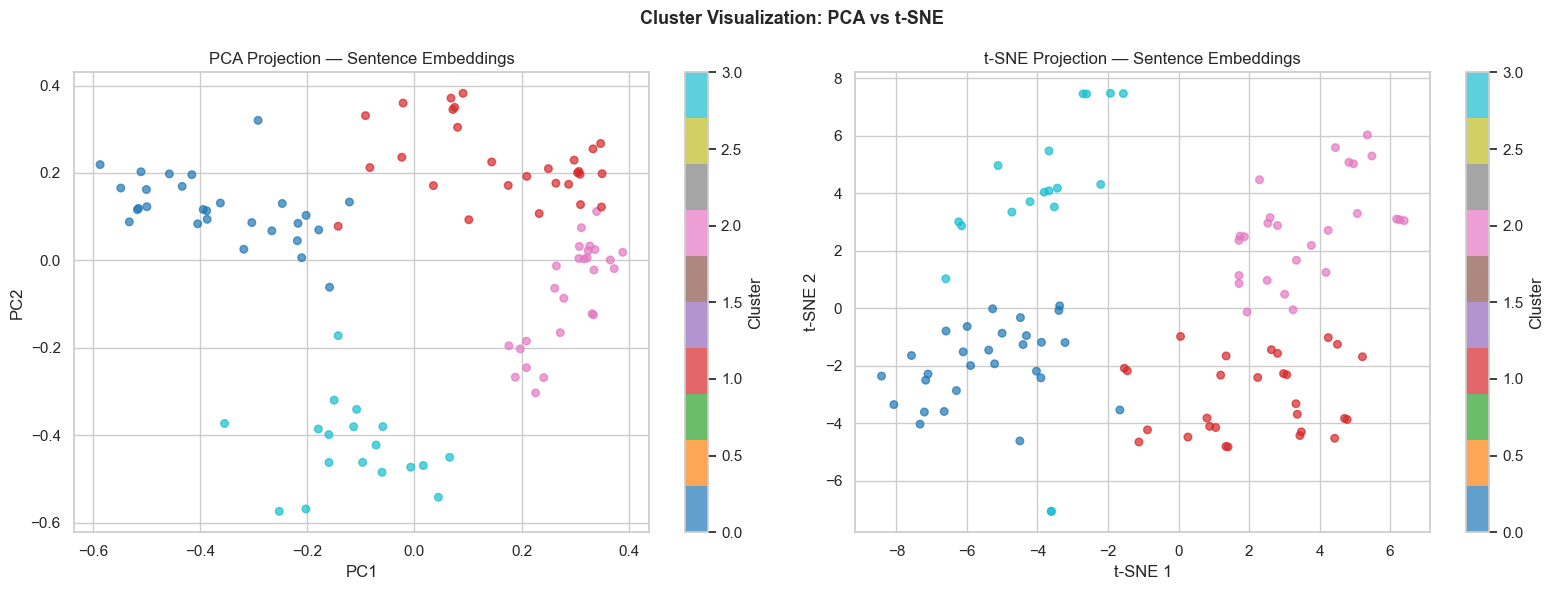

In [64]:
# ─── t-SNE projection — often reveals cluster structure better than PCA (for comparison with PCA result) ──────
from sklearn.manifold import TSNE
import inspect

# scikit-learn renamed TSNE's iteration argument from n_iter to max_iter.
_tsne_kwargs = dict(
    n_components=2,
    random_state=SEED,
    perplexity=min(30, len(embeddings) - 1),
)
if 'max_iter' in inspect.signature(TSNE).parameters:
    _tsne_kwargs['max_iter'] = 1000
else:
    _tsne_kwargs['n_iter'] = 1000

_tsne = TSNE(**_tsne_kwargs)
X_tsne = _tsne.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
sc1 = axes[0].scatter(
    X_2d_emb[:, 0], X_2d_emb[:, 1],
    c=product_df['cluster_emb'], cmap='tab10', alpha=0.7, s=30
)
axes[0].set_title('PCA Projection — Sentence Embeddings')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

# t-SNE
sc2 = axes[1].scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=product_df['cluster_emb'], cmap='tab10', alpha=0.7, s=30
)
axes[1].set_title('t-SNE Projection — Sentence Embeddings')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.suptitle('Cluster Visualization: PCA vs t-SNE', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### Task 2 — Option A vs Option B Comparison

=== Clustering Quality @ K=4 ===
  TF-IDF baseline:       0.1467
  Sentence Embeddings:   0.1610
  Improvement:           +0.0144


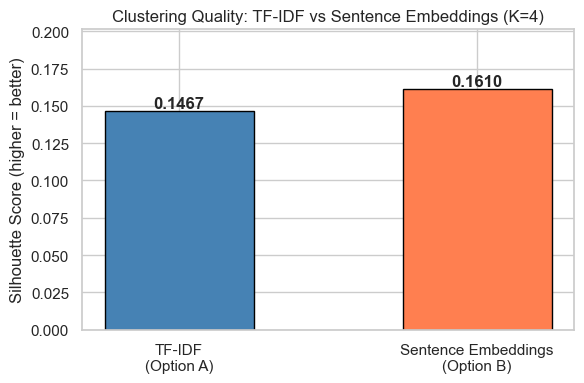

In [65]:
emb_sil_score = silhouette_score(embeddings, product_df['cluster_emb'])

print(f'=== Clustering Quality @ K={K_FINAL} ===')
print(f'  TF-IDF baseline:       {tfidf_sil_score:.4f}')
print(f'  Sentence Embeddings:   {emb_sil_score:.4f}')
print(f'  Improvement:           {emb_sil_score - tfidf_sil_score:+.4f}')

plt.figure(figsize=(6, 4))
bars = plt.bar(
['TF-IDF\n(Option A)', 'Sentence Embeddings\n(Option B)'],
[tfidf_sil_score, emb_sil_score],
color=['steelblue', 'coral'], edgecolor='black', width=0.5
)
for bar, val in zip(bars, [tfidf_sil_score, emb_sil_score]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)
plt.ylabel('Silhouette Score (higher = better)')
plt.title(f'Clustering Quality: TF-IDF vs Sentence Embeddings (K={K_FINAL})')
plt.ylim(0, max(tfidf_sil_score, emb_sil_score) * 1.25)
plt.tight_layout()
plt.show()

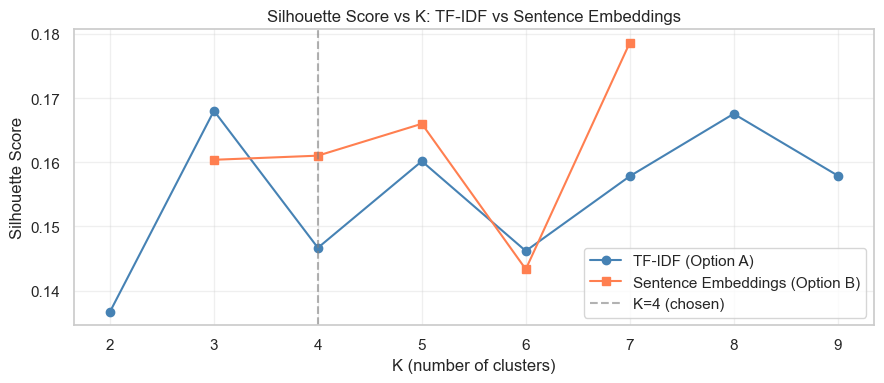

In [66]:
# Recompute TF-IDF silhouette across all K for a fair line chart
sil_scores_tfidf = []
for k in K_range:
    km_t = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    sil_scores_tfidf.append(silhouette_score(X, km_t.fit_predict(X)))

# Rebuild sil_scores_emb from the kmeans_results dict (K_VALUES = [3,4,5,6,7])
sil_scores_emb = [kmeans_results[k]['silhouette'] for k in K_VALUES]
K_range_emb = list(K_VALUES)

plt.figure(figsize=(9, 4))
plt.plot(K_range,     sil_scores_tfidf, marker='o', color='steelblue', label='TF-IDF (Option A)')
plt.plot(K_range_emb, sil_scores_emb,   marker='s', color='coral',     label='Sentence Embeddings (Option B)')
plt.axvline(K_FINAL, color='gray', linestyle='--', alpha=0.6, label=f'K={K_FINAL} (chosen)')
plt.xlabel('K (number of clusters)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K: TF-IDF vs Sentence Embeddings')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

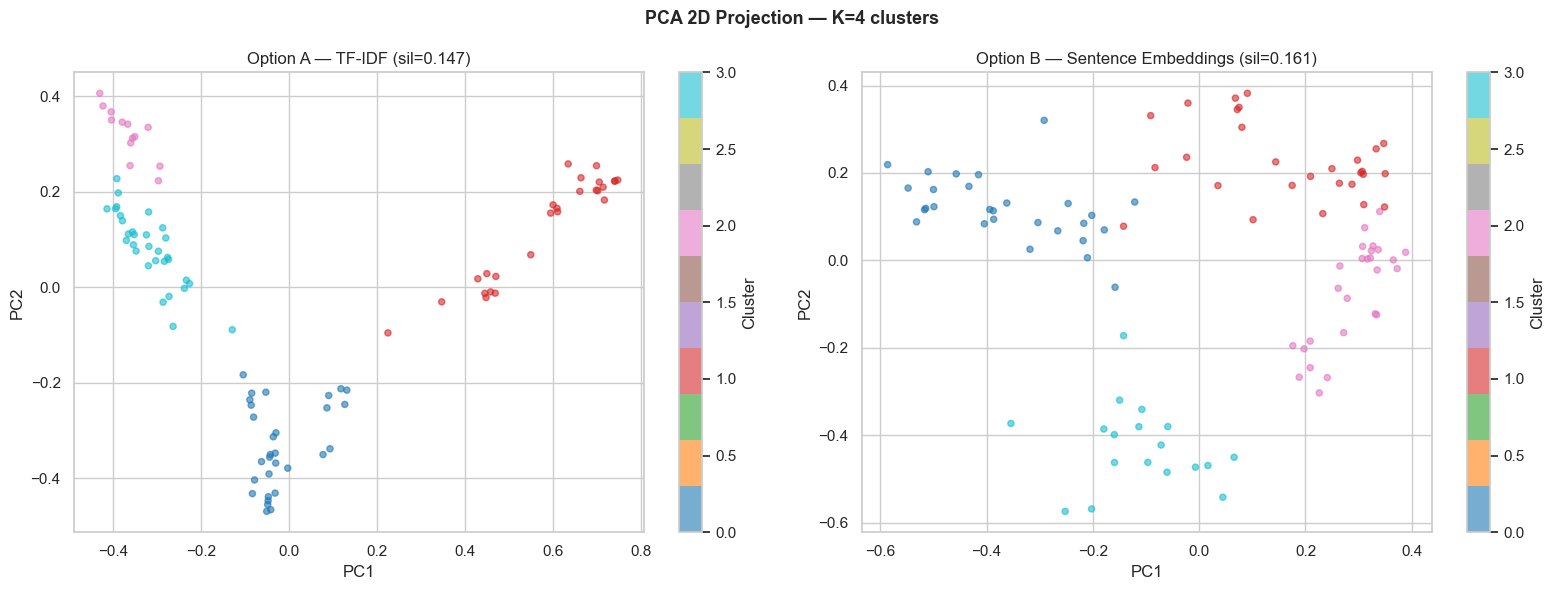

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Option A — TF-IDF (reuse X_2d computed earlier)
sc1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1],
c=product_df['cluster_tfidf'], cmap='tab10', alpha=0.6, s=20)
plt.colorbar(sc1, ax=axes[0], label='Cluster')
axes[0].set_title(f'Option A — TF-IDF (sil={tfidf_sil_score:.3f})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Option B — Sentence Embeddings
sc2 = axes[1].scatter(X_2d_emb[:, 0], X_2d_emb[:, 1],
c=product_df['cluster_emb'], cmap='tab10', alpha=0.6, s=20)
plt.colorbar(sc2, ax=axes[1], label='Cluster')
axes[1].set_title(f'Option B — Sentence Embeddings (sil={emb_sil_score:.3f})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.suptitle(f'PCA 2D Projection — K={K_FINAL} clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

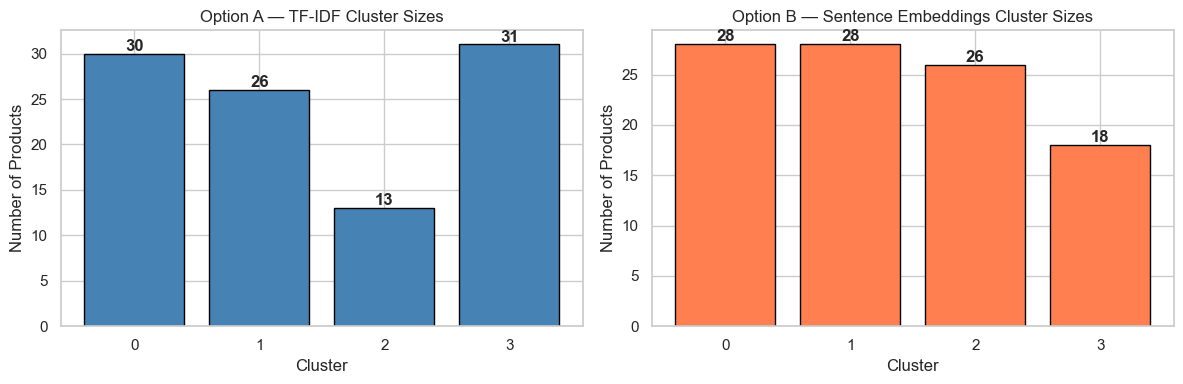

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tfidf_sizes = product_df['cluster_tfidf'].value_counts().sort_index()
emb_sizes   = product_df['cluster_emb'].value_counts().sort_index()

axes[0].bar(tfidf_sizes.index.astype(str), tfidf_sizes.values, color='steelblue', edgecolor='black')
axes[0].set_title('Option A — TF-IDF Cluster Sizes')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Number of Products')
for i, v in enumerate(tfidf_sizes.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

axes[1].bar(emb_sizes.index.astype(str), emb_sizes.values, color='coral', edgecolor='black')
axes[1].set_title('Option B — Sentence Embeddings Cluster Sizes')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Number of Products')
for i, v in enumerate(emb_sizes.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Task 2 Summary

| Metric | TF-IDF (Option A) | Sentence Embeddings (Option B) |
|--------|-------------------|--------------------------------|
| Method | Word frequency counts | Semantic meaning vectors |
| Input level | Product name + categories | Product name + categories |
| Cluster inspection | Top keywords | Sample products + review evidence |
| K used downstream | Baseline comparison only | **K = 4 fixed for Task 3** |
| Final labels | N/A | Tablet; Accessories / Batteries; Smart Home & Audio; Kindle / E-Reader |
| Health handling | N/A | Too few rows for standalone cluster; assigned to nearest embedding cluster |
| Score used | Silhouette | Silhouette + Davies-Bouldin |

**Key takeaway:** sentence embeddings are selected for the downstream pipeline. `K=4` is fixed for the final workflow, and cluster IDs are mapped to four human-readable product groups for Task 3 article generation. Health & Beauty is not separated because it is too small in this dataset to support a grounded article category.


### Task 2 Handoff — Merge Clusters Back To Reviews

Task 2 works at product level. Task 3 needs review-level evidence. This handoff maps every review to its product cluster and creates readable cluster names from the dominant meta-category in each cluster.

In [69]:
# Build readable names for discovered clusters from their actual product contents.
# K-Means cluster IDs can change between reruns, so do not hard-code
# {0: Tablet, 1: Accessories, ...}. Instead, score each cluster by product keywords.
CATEGORY_KEYWORDS = {
    'Tablet': ['fire tablet', 'fire hd', 'tablet', 'kindle fire'],
    'Accessories / Batteries': ['battery', 'batteries', 'charger', 'adapter', 'usb', 'cable', 'case', 'wire', 'sleeve', 'bag', 'keyboard'],
    'Smart Home & Audio': ['echo', 'alexa', 'fire tv', 'speaker', 'bluetooth', 'audio', 'tap'],
    'Kindle / E-Reader': ['kindle paperwhite', 'kindle voyage', 'kindle oasis', 'e-reader', 'ereader', 'paperwhite'],
}

CATEGORY_ORDER = ['Tablet', 'Accessories / Batteries', 'Smart Home & Audio', 'Kindle / E-Reader']

def _cluster_category_scores(group):
    text = ' '.join(
        (group['name'].fillna('') + ' ' + group['categories'].fillna('')).astype(str).tolist()
    ).lower()
    return {
        category: sum(text.count(keyword) for keyword in keywords)
        for category, keywords in CATEGORY_KEYWORDS.items()
    }

# Score every cluster against every expected category.
cluster_scores = {
    int(cluster_id): _cluster_category_scores(group)
    for cluster_id, group in product_df.groupby('cluster_emb')
}

# Greedy one-to-one assignment: strongest cluster/category matches first.
pairs = []
for cluster_id, scores in cluster_scores.items():
    for category, score in scores.items():
        pairs.append((score, cluster_id, category))
pairs.sort(reverse=True)

cluster_name_map = {}
used_categories = set()
for score, cluster_id, category in pairs:
    if cluster_id not in cluster_name_map and category not in used_categories:
        cluster_name_map[cluster_id] = category
        used_categories.add(category)

# Fill any remaining clusters/categories deterministically.
remaining_categories = [c for c in CATEGORY_ORDER if c not in used_categories]
for cluster_id in sorted(cluster_scores):
    if cluster_id not in cluster_name_map:
        cluster_name_map[cluster_id] = remaining_categories.pop(0) if remaining_categories else f'Cluster {cluster_id}: Other / Mixed'

cluster_meta_map = {}
for cluster_id, group in product_df.groupby('cluster_emb'):
    cluster_id = int(cluster_id)
    dominant_meta = group['meta_category'].mode().iloc[0] if 'meta_category' in group else 'Other'
    final_category = cluster_name_map[cluster_id]
    example_products = group['name'].dropna().head(5).tolist()

    cluster_meta_map[cluster_id] = dominant_meta

    print(f'Cluster {cluster_id}: {final_category}  (dominant source meta-category: {dominant_meta})')
    print(f'  keyword scores: {cluster_scores[cluster_id]}')
    for product in example_products:
        print(f'  - {str(product)[:100]}')

product_cluster_lookup = product_df[['name', 'cluster_emb']].dropna(subset=['name']).copy()
product_cluster_lookup['cluster_emb'] = product_cluster_lookup['cluster_emb'].astype(int)
product_cluster_lookup['cluster_name'] = product_cluster_lookup['cluster_emb'].map(cluster_name_map)

# Make this cell rerunnable:
cluster_cols_to_drop = [
    col for col in df.columns
    if col in {'cluster_emb', 'cluster_name'} or col.startswith('cluster_emb_') or col.startswith('cluster_name_')
]
if cluster_cols_to_drop:
    df = df.drop(columns=cluster_cols_to_drop)

# Merge product-level clusters back to review-level rows.
# Some source reviews have missing product names, so they cannot match on `name`.
df = df.merge(product_cluster_lookup, on='name', how='left')

missing_before = int(df['cluster_emb'].isna().sum())
if missing_before:
    print(f'\n{missing_before:,} reviews did not map by product name. Applying meta-category fallback...')

    # Fallback: map each meta-category to the cluster where that meta-category is most common.
    meta_to_cluster = (
        product_df.groupby(['meta_category', 'cluster_emb'])
        .size()
        .reset_index(name='count')
        .sort_values(['meta_category', 'count'], ascending=[True, False])
        .drop_duplicates('meta_category')
        .set_index('meta_category')['cluster_emb']
        .to_dict()
    )
    meta_to_cluster = {k: int(v) for k, v in meta_to_cluster.items()}
    largest_cluster = int(product_df['cluster_emb'].value_counts().idxmax())

    missing_mask = df['cluster_emb'].isna()
    fallback_clusters = df.loc[missing_mask, 'meta_category'].map(meta_to_cluster).fillna(largest_cluster).astype(int)
    df.loc[missing_mask, 'cluster_emb'] = fallback_clusters.values
    df.loc[missing_mask, 'cluster_name'] = df.loc[missing_mask, 'cluster_emb'].astype(int).map(cluster_name_map).values

missing_after = int(df['cluster_emb'].isna().sum())
assert missing_after == 0, f'{missing_after} reviews still have no Task 2 cluster after fallback.'

df['cluster_emb'] = df['cluster_emb'].astype(int)
df['cluster_name'] = df['cluster_name'].fillna(df['cluster_emb'].map(cluster_name_map))

print('\nReview-level final category distribution:')
print(df['cluster_name'].value_counts())
print(f'\nFallback-mapped reviews: {missing_before:,}')

if 'Health & Beauty' in df['meta_category'].values:
    print('\nHealth & Beauty rows are very rare and are not assigned a standalone K=4 cluster:')
    print(df[df['meta_category'] == 'Health & Beauty']['cluster_name'].value_counts().to_string())


Cluster 0: Smart Home & Audio  (dominant source meta-category: E-Readers & Tablets)
  keyword scores: {'Tablet': 34, 'Accessories / Batteries': 73, 'Smart Home & Audio': 272, 'Kindle / E-Reader': 4}
  - All-new Echo (2nd Generation) with improved sound, powered by Dolby, and a new design Walnut Finish
  - Amazon - Amazon Tap Portable Bluetooth and Wi-Fi Speaker - Black,,,
Amazon - Amazon Tap Portable Bl
  - Amazon - Echo Plus w/ Built-In Hub - Silver
  - Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle eReaders,
  - Amazon Echo (1st Generationcertified) Color:White Free Shipping
Cluster 1: Tablet  (dominant source meta-category: E-Readers & Tablets)
  keyword scores: {'Tablet': 195, 'Accessories / Batteries': 9, 'Smart Home & Audio': 29, 'Kindle / E-Reader': 43}
  - All-New Fire 7 Tablet with Alexa, 7" Display, 8 GB - Marine Blue
  - All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Blue Kid-Proof Case
  - All-New Fire HD 8 Kids Editi

In [70]:
# ─── Cluster quality guard — flag tiny clusters before Task 3 ────────────────
MIN_REVIEWS = 10   # clusters with fewer reviews than this will produce weak articles

cluster_counts = df.groupby('cluster_name').size().sort_values()
small = cluster_counts[cluster_counts < MIN_REVIEWS]

if len(small) > 0:
    print(f'⚠️  {len(small)} cluster(s) have < {MIN_REVIEWS} reviews — articles may be weak:')
    print(small.to_string())
else:
    print(f'✓ All clusters have ≥ {MIN_REVIEWS} reviews. Task 3 should be well-grounded.')

print('\nAll cluster review counts:')
for name, cnt in cluster_counts.items():
    flag = ' ⚠️' if cnt < MIN_REVIEWS else ''
    print(f'  {name}: {cnt:,} reviews{flag}')

✓ All clusters have ≥ 10 reviews. Task 3 should be well-grounded.

All cluster review counts:
  Kindle / E-Reader: 4,469 reviews
  Smart Home & Audio: 7,723 reviews
  Accessories / Batteries: 8,711 reviews
  Tablet: 25,635 reviews


In [71]:
# Free the sentence embedding model — clustering is done
for _var in ['embedder', 'embeddings']:
    if _var in globals():
        del globals()[_var]

gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
print('Task 2 embedding model freed')


Task 2 embedding model freed


## 7. Task 3 — Article Generation (Baseline)

In [72]:
GEN_MODEL = 'Qwen/Qwen2.5-1.5B-Instruct'

print(f'Loading generation model: {GEN_MODEL}')
print(' First run will download the model weights — this may take a few minutes...')

gen_pipeline = pipeline(
'text-generation',
model=GEN_MODEL,
device=0 if DEVICE == 'cuda' else -1,
torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
)
print('Model loaded ')

Loading generation model: Qwen/Qwen2.5-1.5B-Instruct
 First run will download the model weights — this may take a few minutes...


Loading weights: 100%|██████████| 338/338 [00:02<00:00, 148.76it/s]


Model loaded 


In [73]:
def build_gen_prompt(category: str, reviews: list) -> str:
    """Build a prompt that instructs the LLM to write a product recommendation article."""
    sample_reviews = '\n'.join([f'- {r[:200]}' for r in reviews]) # truncate each review to 200 chars
    return (
f'You are a product reviewer writing for a consumer guide website.\n\n'
f'Based on the following customer reviews for products in the category "{category}":\n'
f'{sample_reviews}\n\n'
f'Write a short, helpful article (150-200 words) that:\n'
f'1. Recommends the top products and key differences\n'
f'2. Mentions the most common complaints\n'
f'3. Advises which product to avoid and why\n\n'
f'Article:'
)

# Select a balanced mix: 3 positive + 2 negative reviews for the test category
test_category = 'E-Readers & Tablets'
top_reviews = df[(df['meta_category'] == test_category) &
(df['sentiment'] == 'positive')]['clean_text'].head(3).tolist()
bad_reviews = df[(df['meta_category'] == test_category) &
(df['sentiment'] == 'negative')]['clean_text'].head(2).tolist()

prompt = build_gen_prompt(test_category, top_reviews + bad_reviews)
print('=== Prompt Preview ===')
print(prompt[:500] + '...')

=== Prompt Preview ===
You are a product reviewer writing for a consumer guide website.

Based on the following customer reviews for products in the category "E-Readers & Tablets":
- This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.
- great for beginner or experienced person. Bought as a gift and she loves it
- Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype o...


In [74]:
output = gen_pipeline(
prompt,
max_new_tokens=400,
do_sample=True,
temperature=0.5,
top_p=0.9,
repetition_penalty=1.3,
)

generated_text = output[0]['generated_text']
# The model returns the full prompt + generated text — isolate only the article
article = generated_text.split('Article:')[-1].strip()

print(f'=== Generated Article for: {test_category} ===')
print(article)

[transformers] Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'top_p', 'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Generated Article for: E-Readers & Tablets ===
Top E-readers/Tabltes For Beginners - A Buyer's Guide 

When shopping for an e-reader/tablet device suitable for beginners who want something both fun yet functional enough without being too expensive, there is no shortage of options available today! However, each model offers its own unique set-up requirements; hence choosing one can sometimes feel overwhelming due to all these choices out here!

Here’s our list down below:

### Recommended Products  
**Kindle Paperwhite**: Known among readers worldwide because of its durability and excellent reading experience – perfect if you’re new but don’t mind investing more into your purchase than other budget-friendly alternatives. The Kindle Fire HDX 8" also makes quite a splash thanks largely owing to Amazon Prime membership benefits such as free shipping plus access to thousands upon thousand books across various genres including classics and contemporary fiction alike at very affordable ra

In [75]:
# ─── Baseline ROUGE — use HELD-OUT test reviews as reference ─────────────────

test_category = 'E-Readers & Tablets'
_prompt_reviews = set(top_reviews + bad_reviews)   

holdout_pool = test_df[
    (test_df['meta_category'] == test_category) &
    (~test_df['clean_text'].isin(_prompt_reviews))
]['clean_text']

if len(holdout_pool) >= 3:
    holdout_refs = holdout_pool.sample(n=min(5, len(holdout_pool)), random_state=SEED + 1).tolist()
    reference    = ' '.join(holdout_refs)
    _scorer      = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores       = _scorer.score(reference, article)

    print('=== Baseline ROUGE Scores (vs. held-out test reviews — NOT prompt inputs) ===')
    for metric, score in scores.items():
        print(f'  {metric}: P={score.precision:.3f}  R={score.recall:.3f}  F1={score.fmeasure:.3f}')
    print()
    print('Limitation: ROUGE measures n-gram overlap, not factual accuracy or readability.')
    print('Human evaluation is the gold standard for generative article quality.')
else:
    print('Not enough held-out reviews for this category — increase the dataset or relax the filter.')
    scores = None

=== Baseline ROUGE Scores (vs. held-out test reviews — NOT prompt inputs) ===
  rouge1: P=0.100  R=0.297  F1=0.150
  rouge2: P=0.003  R=0.009  F1=0.004
  rougeL: P=0.040  R=0.119  F1=0.060

Limitation: ROUGE measures n-gram overlap, not factual accuracy or readability.
Human evaluation is the gold standard for generative article quality.


## 7.5 Task 3 — LoRA Fine-Tuning (Article Generator)

### Step 1 — Build Product Profiles

In [76]:
# Task 3 now uses Task 2 cluster-aware profiles.
# Each profile combines: cluster/category name, top products, lower-rated products,
# positive review evidence, and negative/neutral complaint evidence.

def _safe_sample_text(series, n, seed=SEED):
    series = series.dropna().drop_duplicates()
    if len(series) == 0:
        return []
    return series.sample(n=min(n, len(series)), random_state=seed).tolist()

def get_cluster_profile(df_src, cluster_name, n_pos=5, n_neg=3):
    """Collect review evidence for one Task 2 cluster/category."""
    cat_df = df_src[df_src['cluster_name'] == cluster_name].copy()
    if cat_df.empty:
        raise ValueError(f'No reviews found for {cluster_name}')

    product_ratings = (
        cat_df.groupby('name')
        .agg(avg_rating=('reviews.rating', 'mean'), count=('reviews.rating', 'count'))
        .sort_values(['avg_rating', 'count'], ascending=[False, False])
    )

    # Prefer products with enough evidence, but fall back gracefully for small clusters.
    robust_products = product_ratings.query('count >= 5')
    if robust_products.empty:
        robust_products = product_ratings

    top_products = robust_products.head(3).index.tolist()
    bottom_products = robust_products.tail(2).index.tolist()

    pos_pool = cat_df[
        (cat_df['name'].isin(top_products)) &
        (cat_df['task1_sentiment'] == 'positive')
    ]['clean_text']
    if len(pos_pool) == 0:
        pos_pool = cat_df[cat_df['task1_sentiment'] == 'positive']['clean_text']

    complaint_pool = cat_df[
        (cat_df['name'].isin(bottom_products)) &
        (cat_df['task1_sentiment'].isin(['negative', 'neutral']))
    ]['clean_text']
    if len(complaint_pool) == 0:
        complaint_pool = cat_df[cat_df['task1_sentiment'].isin(['negative', 'neutral'])]['clean_text']

    return {
        'category': cluster_name,
        'cluster_ids': sorted([int(x) for x in cat_df['cluster_emb'].dropna().unique()]),
        'review_count': int(len(cat_df)),
        'product_count': int(cat_df['name'].nunique()),
        'top_products': top_products,
        'bottom_products': bottom_products,
        'positive_reviews': _safe_sample_text(pos_pool, n_pos),
        'negative_reviews': _safe_sample_text(complaint_pool, n_neg),
    }

category_profiles = {}
for cluster_name in sorted(df['cluster_name'].dropna().unique()):
    try:
        profile = get_cluster_profile(df, cluster_name)
        if len(profile['positive_reviews']) + len(profile['negative_reviews']) < 3:
            print(f'SKIP {cluster_name}: not enough review evidence for a grounded article at K={K_FINAL}')
            continue
        category_profiles[cluster_name] = profile
        print(
            f'OK {cluster_name}: {profile["product_count"]} products, '
            f'{profile["review_count"]:,} reviews, '
            f'{len(profile["positive_reviews"])} positive + {len(profile["negative_reviews"])} complaint examples'
        )
    except Exception as e:
        print(f'SKIP {cluster_name}: {e}')

assert category_profiles, 'No category profiles were created for Task 3.'


OK Accessories / Batteries: 18 products, 8,711 reviews, 5 positive + 3 complaint examples
OK Kindle / E-Reader: 26 products, 4,469 reviews, 5 positive + 3 complaint examples
OK Smart Home & Audio: 28 products, 7,723 reviews, 5 positive + 3 complaint examples
OK Tablet: 28 products, 25,635 reviews, 5 positive + 3 complaint examples


### Step 2 — Generate Reference Articles (Self-Distillation)

In [77]:
NSHOT_EXAMPLE = """\
Example output for category "Batteries & Power":

## Best Batteries & Power Products: Our Top Picks

After analyzing hundreds of customer reviews, the **AmazonBasics AA batteries** stand out as the \
best value option, offering consistent performance at a competitive price point. For heavy users, \
the **Energizer MAX** delivers longer runtime and is worth the premium.

**Top complaints** across all products include shorter-than-advertised battery life and packaging \
issues with bulk packs. Several customers noted inconsistent quality between batches.

**Avoid** the off-brand options — reviewers consistently report premature failure and leakage that \
can damage devices. The small savings are not worth the risk.
"""

def build_reference_prompt(profile):
    """Detailed n-shot prompt used ONLY to generate training data."""
    category  = profile['category']
    pos_text  = '\n'.join([f'- {r[:250]}' for r in profile['positive_reviews']])
    neg_text  = '\n'.join([f'- {r[:250]}' for r in profile['negative_reviews']])
    top_names = ', '.join(profile['top_products'][:3])    if profile['top_products']    else 'N/A'
    bottom_names = ', '.join(profile['bottom_products'][:2]) if profile['bottom_products'] else 'N/A'
    return (
f'You are an expert product reviewer writing for a consumer guide.\n\n'
f'{NSHOT_EXAMPLE}\n---\n'
f'Now write a similar article for the category "{category}".\n\n'
f'Top rated products: {top_names}\n'
f'Lowest rated products: {bottom_names}\n\n'
f'Positive customer reviews:\n{pos_text}\n\n'
f'Negative customer reviews:\n{neg_text}\n\n'
f'Write a helpful article (150-220 words). Use exactly these sections:\n'
f'## Best Products\n'
f'## Key Differences\n'
f'## Common Complaints\n'
f'## Product to Avoid\n'
f'## Final Recommendation\n\n'
f'Requirements:\n'
f'- Mention at least one top-rated product by name.\n'
f'- Mention at least one lower-rated or weaker product by name if available.\n'
f'- Include common complaints based only on the negative reviews.\n'
f'- Do not invent products that are not listed above.\n\n'
f'Article:\n'
)

# Preview
sample_profile = list(category_profiles.values())[0]
print('=== Sample Reference Prompt (first 500 chars) ===')
print(build_reference_prompt(sample_profile)[:500] + '...')

=== Sample Reference Prompt (first 500 chars) ===
You are an expert product reviewer writing for a consumer guide.

Example output for category "Batteries & Power":

## Best Batteries & Power Products: Our Top Picks

After analyzing hundreds of customer reviews, the **AmazonBasics AA batteries** stand out as the best value option, offering consistent performance at a competitive price point. For heavy users, the **Energizer MAX** delivers longer runtime and is worth the premium.

**Top complaints** across all products include shorter-than-adver...


In [78]:
ARTICLES_PER_CATEGORY = 8  # stronger generator fine-tuning: K=4 x 8 = up to 32 examples
reference_articles = []

# Recreate base generation pipeline if this cell is rerun after later cleanup.
if 'gen_pipeline' not in globals():
    print('gen_pipeline not found — reloading base generation model...')
    gen_pipeline = pipeline(
        'text-generation',
        model=GEN_MODEL,
        device=0 if DEVICE == 'cuda' else -1,
        torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
    )
    print('Base generation model reloaded.')


for cat, profile in category_profiles.items():
    print(f'Generating reference articles for: {cat}...')
    prompt = build_reference_prompt(profile)
    for i in range(ARTICLES_PER_CATEGORY):
        out = gen_pipeline(
            prompt,
            max_new_tokens=300,
            do_sample=True,
            temperature=0.7 + i * 0.05,
            top_p=0.9,
            repetition_penalty=1.15,
        )
        generated = out[0]['generated_text'].split('Article:')[-1].strip()
        if len(generated.split()) >= 50:
            reference_articles.append({
                'category': cat,
                'prompt': prompt,
                'article': generated,
            })

expected_max = ARTICLES_PER_CATEGORY * len(category_profiles)
print(f'\nGenerated {len(reference_articles)} reference articles total (max possible: {expected_max})')
assert reference_articles, 'No reference articles generated.'
print('\n=== Sample Reference Article ===')
print(f'Category: {reference_articles[0]["category"]}')
print(reference_articles[0]['article'][:400])


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating reference articles for: Accessories / Batteries...


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Generating reference articles for: Kindle / E-Reader...


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Generating reference articles for: Smart Home & Audio...


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Generating reference articles for: Tablet...


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


Generated 32 reference articles total (max possible: 32)

=== Sample Reference Article ===
Category: Accessories / Batteries
### Best Accessories/Batteries Products:

#### **Best Products**
*Expanding Accordion File Folder Plastic Portable Document Organizer Letter Size*
This expanding accordion file organizer provides ample space for documents, notebooks, and various papers while featuring convenient over-the-shoulder handles or easy grip carrying strap. It's durable yet lightweight, making it ideal for both personal u


In [79]:
with open('reference_articles.json', 'w') as _f:
    json.dump(reference_articles, _f, indent=2, ensure_ascii=False)
print(f'Saved {len(reference_articles)} reference articles -> reference_articles.json')

Saved 32 reference articles -> reference_articles.json


In [80]:
def build_simple_gen_prompt(profile):
    """Short grounded prompt used at inference time after fine-tuning."""
    category = profile['category']
    top_products = '\n'.join([f'- {p}' for p in profile['top_products']]) or '- Not enough product evidence'
    bottom_products = '\n'.join([f'- {p}' for p in profile['bottom_products']]) or '- Not enough product evidence'
    reviews = profile['positive_reviews'][:3] + profile['negative_reviews'][:2]
    reviews_text = '\n'.join([f'- {r[:220]}' for r in reviews])

    return (
        f'Write a product recommendation article for "{category}".\n\n'
        f'Use ONLY these products and review evidence. Do not invent unrelated products.\n\n'
        f'Top products from the data:\n{top_products}\n\n'
        f'Products with weaker feedback or complaints:\n{bottom_products}\n\n'
        f'Customer review evidence:\n{reviews_text}\n\n'
        f'Use exactly these sections:\n'
        f'## Best Products\n'
        f'## Key Differences\n'
        f'## Common Complaints\n'
        f'## Product to Avoid\n'
        f'## Final Recommendation\n\n'
        f'Requirements:\n'
        f'- Mention at least one top product by name.\n'
        f'- Mention at least one weaker product or complaint if available.\n'
        f'- Explain why a customer should choose one product over another.\n'
        f'- Do not mention products outside the evidence list.\n\n'
        f'Article:\n'
    )

def format_gen_training_example(item):
    profile = category_profiles.get(item['category'])
    if profile is None:
        return None
    simple_prompt = build_simple_gen_prompt(profile)
    return {'text': simple_prompt + item['article']}

gen_train_examples = [
    fmt for item in reference_articles
    if (fmt := format_gen_training_example(item)) is not None
]

print(f'Training examples ready: {len(gen_train_examples)}')
assert gen_train_examples, 'No generation training examples available.'
print('\n=== Sample training example (first 400 chars) ===')
print(gen_train_examples[0]['text'][:400] + '...')


Training examples ready: 32

=== Sample training example (first 400 chars) ===
Write a product recommendation article for "Accessories / Batteries".

Use ONLY these products and review evidence. Do not invent unrelated products.

Top products from the data:
- Expanding Accordion File Folder Plastic Portable Document Organizer Letter Size
- AmazonBasics USB 3.0 Cable - A-Male to B-Male - 6 Feet (1.8 Meters)
- AmazonBasics 15.6-Inch Laptop and Tablet Bag

Products with weaker ...


### Step 3 — Load Model + Apply LoRA

In [81]:
# Free the base generation pipeline 
del gen_pipeline
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
elif torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Base pipeline freed')


Base pipeline freed


In [82]:
print('Loading model for fine-tuning...')

# MPS-safe device setup (device_map='auto' conflicts with PEFT on MPS)
if torch.cuda.is_available():
    _gen_device    = 'cuda'
    _gen_dtype     = torch.float16
    _gen_device_map = 'auto'
elif torch.backends.mps.is_available():
    _gen_device    = 'mps'
    _gen_dtype     = torch.float32
    _gen_device_map = None   # device_map='auto' causes PEFT key errors on MPS
else:
    _gen_device    = 'cpu'
    _gen_dtype     = torch.float32
    _gen_device_map = None

print(f'Generator device: {_gen_device}')

gen_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
gen_tokenizer.pad_token = gen_tokenizer.eos_token
gen_tokenizer.padding_side = 'right'

gen_base_model = AutoModelForCausalLM.from_pretrained(
MODEL_NAME,
dtype=_gen_dtype,
**(({'device_map': _gen_device_map}) if _gen_device_map else {}),
)
if _gen_device_map is None:
    gen_base_model = gen_base_model.to(_gen_device)

# LoRA config 
gen_lora_config = LoraConfig(
r=16,
lora_alpha=32,
target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj'],
lora_dropout=0.05,
bias='none',
task_type=TaskType.CAUSAL_LM,
)

gen_model = get_peft_model(gen_base_model, gen_lora_config)
print('LoRA applied')
gen_model.print_trainable_parameters()

Loading model for fine-tuning...
Generator device: mps


Loading weights: 100%|██████████| 338/338 [00:02<00:00, 165.41it/s]


LoRA applied
trainable params: 13,762,560 || all params: 1,557,476,864 || trainable%: 0.8836


### Step 4 — Fine-Tune with SFTTrainer

In [83]:
gen_hf_dataset = Dataset.from_list(gen_train_examples)

gen_training_args = SFTConfig(
    output_dir='./generator_lora_model',
    num_train_epochs=5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    warmup_ratio=0.1,
    fp16=(_gen_device == 'cuda'),  # float16 only on CUDA
    bf16=False,                    # avoid TRL auto-enabling bf16 on CPU/Docker
    use_cpu=(_gen_device == 'cpu'),
    logging_steps=1,  # log every step so the small Task 3 dataset produces a useful loss curve,
    save_strategy='epoch',
    report_to='none',
    dataset_text_field='text',
    seed=SEED,
)

gen_trainer = SFTTrainer(
    model=gen_model,
    args=gen_training_args,
    train_dataset=gen_hf_dataset,
    processing_class=gen_tokenizer,
)

print('Starting fine-tuning...')
print(f'Training on {len(gen_hf_dataset)} examples x {gen_training_args.num_train_epochs} epochs')
gen_trainer.train()
print('\nFine-tuning complete')


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Tokenizing train dataset: 100%|██████████| 32/32 [00:00<00:00, 920.79 examples/s]
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Starting fine-tuning...
Training on 32 examples x 5 epochs


Step,Training Loss
1,2.820116
2,2.803124
3,2.741574
4,2.628673
5,2.615422
6,2.512569
7,2.529035
8,2.438323
9,2.467323
10,2.402477



Fine-tuning complete


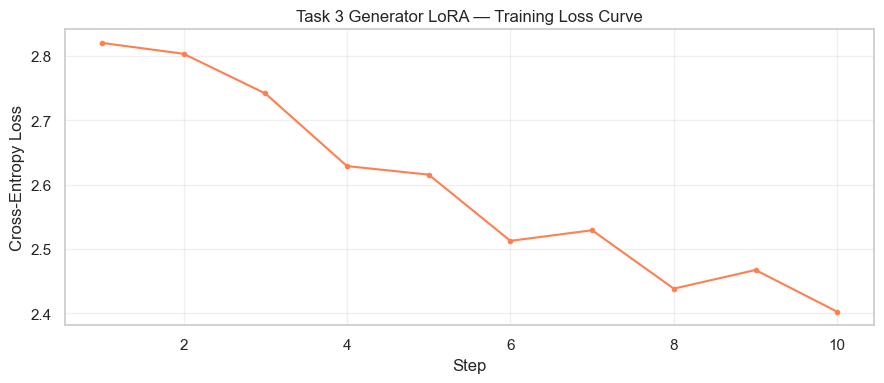

Initial: 2.8201  →  Final: 2.4025
Loss decreased but is still changing — consider more epochs if output quality is weak.


In [84]:
# ─── Training loss curve (Task 3 Generator LoRA) ────────────────────────────
_glog = gen_trainer.state.log_history
_glosses = [(e['step'], e['loss']) for e in _glog if 'loss' in e]

if _glosses:
    _gs, _gl = zip(*_glosses)
    plt.figure(figsize=(9, 4))
    plt.plot(_gs, _gl, marker='o', markersize=3, linewidth=1.5, color='coral')
    plt.title('Task 3 Generator LoRA — Training Loss Curve')
    plt.xlabel('Step'); plt.ylabel('Cross-Entropy Loss')
    plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f'Initial: {_gl[0]:.4f}  →  Final: {_gl[-1]:.4f}')
    if len(_gl) == 1:
        print('Only one loss point was logged. With a small generator dataset, use logging_steps=1 and/or more training examples to assess convergence.')
    elif abs(_gl[-1] - _gl[-2]) < 0.002:
        print('✓ Loss has converged — epoch count looks appropriate.')
    elif _gl[-1] < _gl[0]:
        print('Loss decreased but is still changing — consider more epochs if output quality is weak.')
    else:
        print('Loss did not decrease overall — consider lowering learning rate or checking training data quality.')
else:
    print('No loss history available — check logging_steps and confirm gen_trainer.train() ran successfully.')


In [85]:
gen_model.save_pretrained('./generator_lora_model')
gen_tokenizer.save_pretrained('./generator_lora_model')
print('Generator saved -> ./generator_lora_model')

Generator saved -> ./generator_lora_model


### Step 5 — Evaluate: Base vs Fine-Tuned (ROUGE)

In [86]:
# Phase A: Base model articles (gen_model with LoRA adapter disabled)
gen_model.eval()
gen_model.disable_adapter_layers()

base_gen_pipeline = hf_pipeline(
    'text-generation',
    model=gen_model,
    tokenizer=gen_tokenizer,
    device=_gen_device,
)

GEN_PARAMS = dict(
    max_new_tokens=300,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.15,
)

gen_results = []
base_articles_cache = {}

print('Generating base-model articles...')
for cat, profile in category_profiles.items():
    simple_prompt = build_simple_gen_prompt(profile)
    out = base_gen_pipeline(simple_prompt, **GEN_PARAMS)
    base_art = out[0]['generated_text'].split('Article:')[-1].strip()
    base_articles_cache[cat] = base_art
    print(f'  Done: {cat}')

del base_gen_pipeline
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
print('Base articles generated')


Generating base-model articles...


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Done: Accessories / Batteries


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Done: Kindle / E-Reader


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Done: Smart Home & Audio
  Done: Tablet
Base articles generated


In [87]:
# Phase B: Fine-tuned articles (re-enable LoRA adapter)
gen_model.enable_adapter_layers()

ft_gen_pipeline = hf_pipeline(
    'text-generation',
    model=gen_model,
    tokenizer=gen_tokenizer,
    device=_gen_device,
)

# Self-contained ROUGE scorer for this evaluation cell.
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

gen_results = []  # reset so rerunning this cell does not duplicate categories
print('Generating fine-tuned articles and evaluating every category...')
for cat, profile in category_profiles.items():
    simple_prompt = build_simple_gen_prompt(profile)
    cat_refs = [a['article'] for a in reference_articles if a['category'] == cat]
    if not cat_refs:
        print(f'  Skipping {cat}: no reference article available')
        continue

    reference = cat_refs[0]
    base_art = base_articles_cache[cat]
    out = ft_gen_pipeline(simple_prompt, **GEN_PARAMS)
    ft_art = out[0]['generated_text'].split('Article:')[-1].strip()

    base_rouge = scorer.score(reference, base_art)
    ft_rouge = scorer.score(reference, ft_art)

    gen_results.append({
        'category': cat,
        'base_rouge1': round(base_rouge['rouge1'].fmeasure, 3),
        'base_rouge2': round(base_rouge['rouge2'].fmeasure, 3),
        'base_rougeL': round(base_rouge['rougeL'].fmeasure, 3),
        'ft_rouge1': round(ft_rouge['rouge1'].fmeasure, 3),
        'ft_rouge2': round(ft_rouge['rouge2'].fmeasure, 3),
        'ft_rougeL': round(ft_rouge['rougeL'].fmeasure, 3),
        'base_article': base_art,
        'ft_article': ft_art,
        'reference_article': reference,
    })
    print(
        f'  {cat} — Base ROUGE-L: {base_rouge["rougeL"].fmeasure:.3f} | '
        f'FT ROUGE-L: {ft_rouge["rougeL"].fmeasure:.3f}'
    )

gen_results_df = pd.DataFrame(gen_results)
assert not gen_results_df.empty, 'No generation evaluation results were created.'

# Make plotting robust: if a category appears more than once after reruns or merged clusters,
# keep one row per final category by averaging metric columns and keeping the first article text.
_metric_cols = ['base_rouge1', 'base_rouge2', 'base_rougeL', 'ft_rouge1', 'ft_rouge2', 'ft_rougeL']
_text_cols = ['base_article', 'ft_article', 'reference_article']
if gen_results_df['category'].duplicated().any():
    print('Duplicate generation categories detected; aggregating to one row per category for plots/results.')
    gen_results_df = (
        gen_results_df
        .groupby('category', as_index=False)
        .agg({**{c: 'mean' for c in _metric_cols}, **{c: 'first' for c in _text_cols}})
    )
    gen_results_df[_metric_cols] = gen_results_df[_metric_cols].round(3)

print('\nEvaluation complete')


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating fine-tuned articles and evaluating every category...


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Accessories / Batteries — Base ROUGE-L: 0.245 | FT ROUGE-L: 0.231


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Kindle / E-Reader — Base ROUGE-L: 0.154 | FT ROUGE-L: 0.129


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Smart Home & Audio — Base ROUGE-L: 0.171 | FT ROUGE-L: 0.153
  Tablet — Base ROUGE-L: 0.192 | FT ROUGE-L: 0.150

Evaluation complete


In [88]:
print('=== ROUGE Scores: Base vs Fine-Tuned ===')
display_cols = [
    'category',
    'base_rouge1', 'ft_rouge1',
    'base_rouge2', 'ft_rouge2',
    'base_rougeL', 'ft_rougeL',
]
print(gen_results_df[display_cols].to_string(index=False))

print('\n=== Average ROUGE Scores ===')
for model_label, prefix in [('Base', 'base'), ('Fine-tuned', 'ft')]:
    r1 = gen_results_df[f'{prefix}_rouge1'].mean()
    r2 = gen_results_df[f'{prefix}_rouge2'].mean()
    rl = gen_results_df[f'{prefix}_rougeL'].mean()
    print(f'{model_label:<10} — ROUGE-1: {r1:.3f} | ROUGE-2: {r2:.3f} | ROUGE-L: {rl:.3f}')


=== ROUGE Scores: Base vs Fine-Tuned ===
               category  base_rouge1  ft_rouge1  base_rouge2  ft_rouge2  base_rougeL  ft_rougeL
Accessories / Batteries        0.533      0.466        0.167      0.147        0.245      0.231
      Kindle / E-Reader        0.443      0.371        0.094      0.063        0.154      0.129
     Smart Home & Audio        0.446      0.430        0.068      0.073        0.171      0.153
                 Tablet        0.449      0.399        0.135      0.109        0.192      0.150

=== Average ROUGE Scores ===
Base       — ROUGE-1: 0.468 | ROUGE-2: 0.116 | ROUGE-L: 0.191
Fine-tuned — ROUGE-1: 0.416 | ROUGE-2: 0.098 | ROUGE-L: 0.166


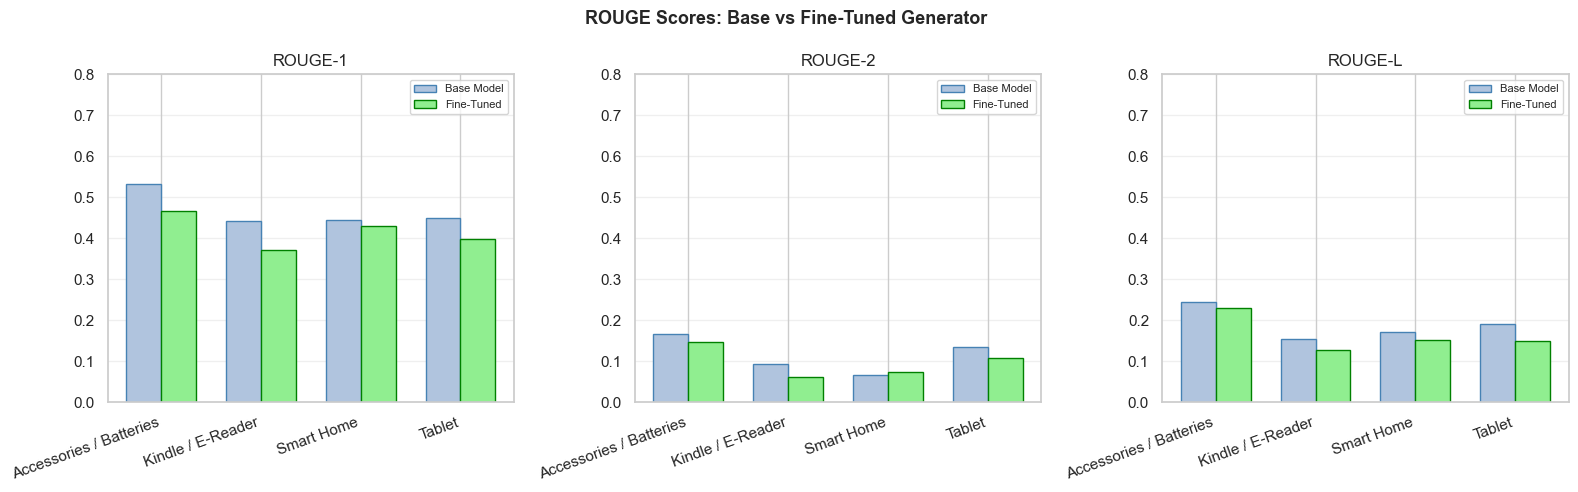

In [89]:
# Use one row per final category for plotting, even if previous reruns created duplicates.
_plot_df = gen_results_df.copy()
_metric_cols = ['base_rouge1', 'base_rouge2', 'base_rougeL', 'ft_rouge1', 'ft_rouge2', 'ft_rougeL']
if _plot_df['category'].duplicated().any():
    _plot_df = _plot_df.groupby('category', as_index=False)[_metric_cols].mean()
    _plot_df[_metric_cols] = _plot_df[_metric_cols].round(3)
else:
    _plot_df = _plot_df[['category'] + _metric_cols]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('rouge1', 'ROUGE-1'), ('rouge2', 'ROUGE-2'), ('rougeL', 'ROUGE-L')]

for ax, (metric, title) in zip(axes, metrics):
    _x = np.arange(len(_plot_df))
    _w = 0.35
    bars1 = ax.bar(_x - _w/2, _plot_df[f'base_{metric}'],
                   _w, label='Base Model', color='lightsteelblue', edgecolor='steelblue')
    bars2 = ax.bar(_x + _w/2, _plot_df[f'ft_{metric}'],
                   _w, label='Fine-Tuned',  color='lightgreen',    edgecolor='green')
    ax.set_title(title)
    ax.set_xticks(_x)
    ax.set_xticklabels([c.split(' & ')[0] for c in _plot_df['category']], rotation=20, ha='right')
    ax.set_ylim(0, 0.8)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('ROUGE Scores: Base vs Fine-Tuned Generator', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

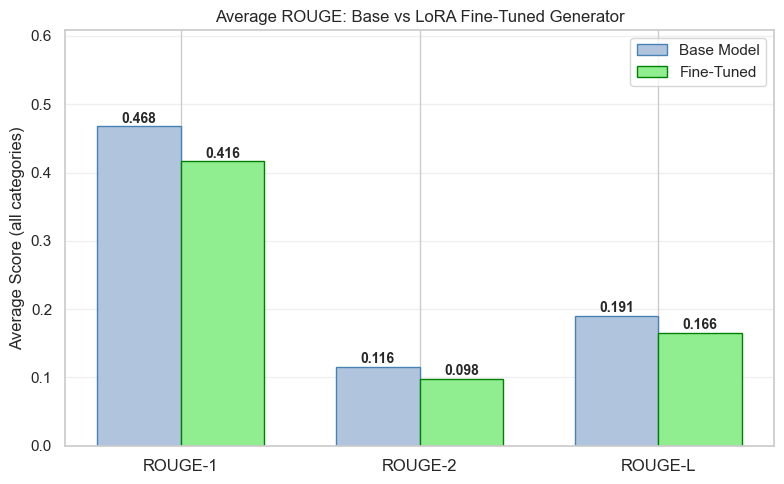

In [90]:
_avg_df = gen_results_df.copy()
_metric_cols = ['base_rouge1', 'base_rouge2', 'base_rougeL', 'ft_rouge1', 'ft_rouge2', 'ft_rougeL']
if _avg_df['category'].duplicated().any():
    _avg_df = _avg_df.groupby('category', as_index=False)[_metric_cols].mean()

avg_base = [_avg_df['base_rouge1'].mean(),
            _avg_df['base_rouge2'].mean(),
            _avg_df['base_rougeL'].mean()]
avg_ft   = [_avg_df['ft_rouge1'].mean(),
            _avg_df['ft_rouge2'].mean(),
            _avg_df['ft_rougeL'].mean()]
metric_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']

_x = np.arange(3)
_w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(_x - _w/2, avg_base, _w, label='Base Model', color='lightsteelblue', edgecolor='steelblue')
b2 = ax.bar(_x + _w/2, avg_ft,   _w, label='Fine-Tuned',  color='lightgreen',    edgecolor='green')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(_x); ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylim(0, max(max(avg_base), max(avg_ft)) * 1.3)
ax.set_ylabel('Average Score (all categories)')
ax.set_title('Average ROUGE: Base vs LoRA Fine-Tuned Generator')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [91]:
sep70 = '=' * 70
sep50 = '-' * 50
for _, row in gen_results_df.iterrows():
    print(sep70)
    print(f'CATEGORY: {row["category"]}')
    print(sep70)
    print(f'\nBASE MODEL  (ROUGE-L: {row["base_rougeL"]})')
    print(sep50)
    print(row['base_article'][:500])
    print(f'\nFINE-TUNED  (ROUGE-L: {row["ft_rougeL"]})')
    print(sep50)
    print(row['ft_article'][:500])
    print()

CATEGORY: Accessories / Batteries

BASE MODEL  (ROUGE-L: 0.245)
--------------------------------------------------
**Best Products:**
For anyone in need of an efficient and versatile accessory or battery solution, consider expanding upon your current setup with either the **Expanding Accordion File Folder Plastic Portable Document Organizer Letter Size** or the **AmazonBasics USB 3.0 Cable - A-Male to B-Male - 6 Feet (1.8 Meters)**.

### Top Product Recommendations:

#### **Expanding Accordion File Folder Plastic Portable Document Organizer Letter Size**

This organizer offers a compact yet expansive design 

FINE-TUNED  (ROUGE-L: 0.231)
--------------------------------------------------
### Accessory Recommendations: Which Accessories Should You Buy?

In today's world, having the right accessories can make all the difference in how efficiently we use our devices. Whether you're looking for storage solutions like file folders or cooling options for your laptops, there are plenty of gre

### Step 6 — Generate Final Articles for All Categories

In [92]:
def _product_mentioned(article: str, product_name: str) -> bool:
    """Loose product-name match that works with long Amazon product titles."""
    article_l = str(article).lower()
    product_l = str(product_name).lower()
    if not product_l.strip():
        return False

    # Full-prefix check for long names.
    if product_l[:30] in article_l:
        return True

    # Token overlap check for partially shortened product names.
    tokens = [t for t in re.findall(r'[a-z0-9]+', product_l) if len(t) >= 4]
    if not tokens:
        return False
    important = tokens[:8]
    hits = sum(t in article_l for t in important)
    return hits >= max(2, min(4, len(important) // 2))

def article_check(article: str, profile: dict) -> dict:
    """Automatic quality checks for Task 3 generated articles."""
    article_l = str(article).lower()
    top_products = profile.get('top_products', [])
    weak_products = profile.get('bottom_products', [])
    evidence_products = top_products + weak_products

    mentioned_products = [p for p in evidence_products if _product_mentioned(article, p)]
    mentioned_top = [p for p in top_products if _product_mentioned(article, p)]
    mentioned_weak = [p for p in weak_products if _product_mentioned(article, p)]

    complaint_terms = ['complaint', 'complaints', 'issue', 'issues', 'problem', 'problems',
                       'drawback', 'drawbacks', 'weakness', 'weaknesses', 'avoid', 'poor', 'negative']
    recommendation_terms = ['recommend', 'best', 'choose', 'top pick', 'worth', 'ideal', 'better for']
    required_sections = ['best products', 'key differences', 'common complaints',
                         'product to avoid', 'final recommendation']

    section_hits = {section: section in article_l for section in required_sections}
    hallucination_terms = ['backpack', 'brand name', '[brand name]', 'off-brand']
    possible_hallucination = any(term in article_l for term in hallucination_terms)

    return {
        'mentions_top_product': bool(mentioned_top),
        'mentions_weak_product': bool(mentioned_weak),
        'mentions_complaints': any(term in article_l for term in complaint_terms),
        'has_recommendation_language': any(term in article_l for term in recommendation_terms),
        'required_sections_present': sum(section_hits.values()),
        'required_sections_total': len(required_sections),
        'required_section_rate': round(sum(section_hits.values()) / len(required_sections), 3),
        'evidence_products_available': len(evidence_products),
        'direct_product_mentions_detected': len(mentioned_products),
        'grounding_rate': round(len(mentioned_products) / max(1, len(evidence_products)), 3),
        'possible_hallucination_flag': possible_hallucination,
    }

gen_final_articles = {}
article_quality_checks = []

for cat, profile in category_profiles.items():
    simple_prompt = build_simple_gen_prompt(profile)
    out = ft_gen_pipeline(
        simple_prompt,
        max_new_tokens=400,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.15,
    )
    article = out[0]['generated_text'].split('Article:')[-1].strip()
    gen_final_articles[cat] = article

    checks = article_check(article, profile)
    checks.update({
        'category': cat,
        'article_chars': len(article),
    })
    article_quality_checks.append(checks)
    print(f'Generated: {cat}')

with open('final_articles.json', 'w') as _f:
    json.dump(gen_final_articles, _f, indent=2, ensure_ascii=False)

article_quality_df = pd.DataFrame(article_quality_checks)
print('\nFinal articles saved -> final_articles.json')
display(article_quality_df)


[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated: Accessories / Batteries


[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated: Kindle / E-Reader


[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated: Smart Home & Audio
Generated: Tablet

Final articles saved -> final_articles.json


,mentions_top_product,mentions_weak_product,mentions_complaints,has_recommendation_language,required_sections_present,required_sections_total,required_section_rate,evidence_products_available,direct_product_mentions_detected,grounding_rate,possible_hallucination_flag,category,article_chars
0,True,True,True,True,4,5,0.8,5,4,0.8,False,Accessories / Batteries,2480
1,True,True,False,True,1,5,0.2,5,5,1.0,False,Kindle / E-Reader,2305
2,True,False,False,True,1,5,0.2,5,2,0.4,False,Smart Home & Audio,2714
3,True,True,True,True,2,5,0.4,5,4,0.8,False,Tablet,2626


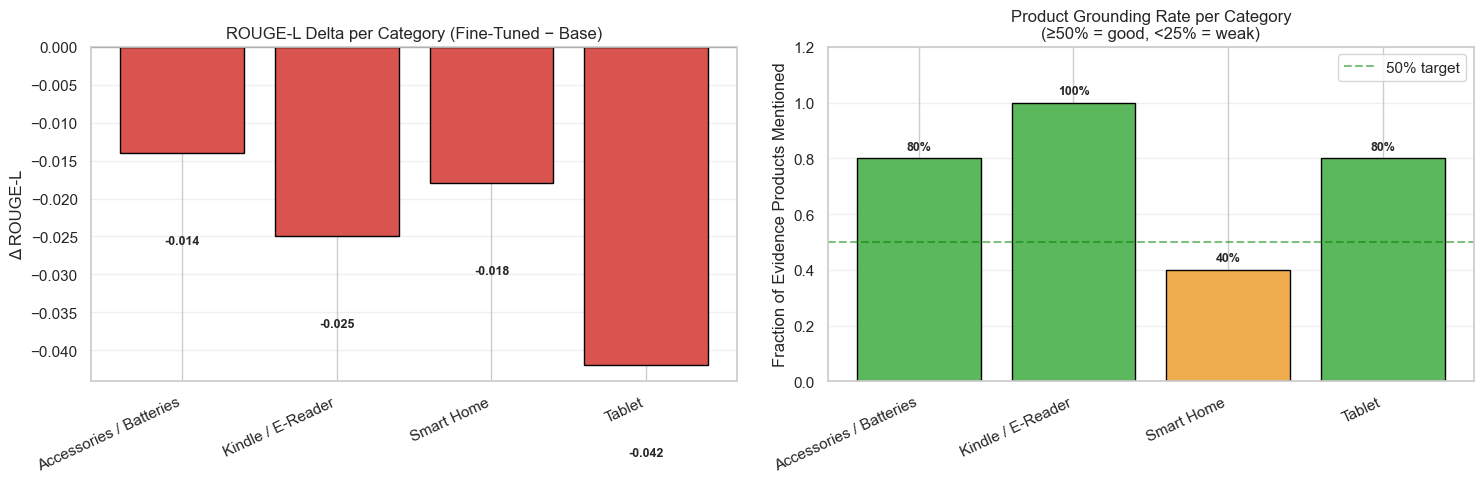

In [93]:
# ─── ROUGE-L improvement delta + grounding rate bar chart ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: per-category ROUGE-L delta
deltas = gen_results_df['ft_rougeL'] - gen_results_df['base_rougeL']
_colors = ['#5cb85c' if d >= 0 else '#d9534f' for d in deltas]
axes[0].bar(range(len(gen_results_df)), deltas, color=_colors, edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('ROUGE-L Delta per Category (Fine-Tuned − Base)')
axes[0].set_ylabel('Δ ROUGE-L')
axes[0].set_xticks(range(len(gen_results_df)))
axes[0].set_xticklabels([c.split(' & ')[0] for c in gen_results_df['category']],
                         rotation=25, ha='right')
for i, d in enumerate(deltas):
    axes[0].text(i, d + (0.004 if d >= 0 else -0.012),
                 f'{d:+.3f}', ha='center', fontsize=9, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Right: grounding rate (fraction of evidence products mentioned in the article)
if 'article_quality_df' in globals() and not article_quality_df.empty:
    article_quality_df = article_quality_df.copy()
    article_quality_df['grounding_rate'] = (
        article_quality_df['direct_product_mentions_detected'] /
        article_quality_df['evidence_products_available'].clip(lower=1)
    )
    _gr_colors = ['#5cb85c' if v >= 0.5 else '#f0ad4e' if v >= 0.25 else '#d9534f'
                  for v in article_quality_df['grounding_rate']]
    axes[1].bar(range(len(article_quality_df)), article_quality_df['grounding_rate'],
                color=_gr_colors, edgecolor='black')
    axes[1].set_title('Product Grounding Rate per Category\n(≥50% = good, <25% = weak)')
    axes[1].set_ylabel('Fraction of Evidence Products Mentioned')
    axes[1].set_ylim(0, 1.2)
    axes[1].set_xticks(range(len(article_quality_df)))
    axes[1].set_xticklabels([c.split(' & ')[0] for c in article_quality_df['category']],
                              rotation=25, ha='right')
    for i, v in enumerate(article_quality_df['grounding_rate']):
        axes[1].text(i, v + 0.03, f'{v:.0%}', ha='center', fontsize=9, fontweight='bold')
    axes[1].axhline(0.5, color='green', linestyle='--', alpha=0.5, label='50% target')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Run final article generation first',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Grounding Rate (not yet available)')

plt.tight_layout(); plt.show()

In [94]:
# ─── Automatic Task 3 Requirement Checks ───────────────────────────────────
# These checks complement ROUGE and reduce reliance on manual inspection.
required_cols = [
    'mentions_top_product',
    'mentions_weak_product',
    'mentions_complaints',
    'has_recommendation_language',
    'required_section_rate',
    'grounding_rate',
    'possible_hallucination_flag',
]

print('=== Automatic Task 3 Requirement Checks ===')
display(article_quality_df[['category'] + required_cols])

summary_checks = {
    'categories_checked': int(len(article_quality_df)),
    'mentions_top_product_rate': round(float(article_quality_df['mentions_top_product'].mean()), 3),
    'mentions_weak_product_rate': round(float(article_quality_df['mentions_weak_product'].mean()), 3),
    'mentions_complaints_rate': round(float(article_quality_df['mentions_complaints'].mean()), 3),
    'recommendation_language_rate': round(float(article_quality_df['has_recommendation_language'].mean()), 3),
    'avg_required_section_rate': round(float(article_quality_df['required_section_rate'].mean()), 3),
    'avg_grounding_rate': round(float(article_quality_df['grounding_rate'].mean()), 3),
    'hallucination_flags': int(article_quality_df['possible_hallucination_flag'].sum()),
}

print('\nSummary:')
for k, v in summary_checks.items():
    print(f'  {k}: {v}')


=== Automatic Task 3 Requirement Checks ===


,category,mentions_top_product,mentions_weak_product,mentions_complaints,has_recommendation_language,required_section_rate,grounding_rate,possible_hallucination_flag
0,Accessories / Batteries,True,True,True,True,0.8,0.8,False
1,Kindle / E-Reader,True,True,False,True,0.2,1.0,False
2,Smart Home & Audio,True,False,False,True,0.2,0.4,False
3,Tablet,True,True,True,True,0.4,0.8,False



Summary:
  categories_checked: 4
  mentions_top_product_rate: 1.0
  mentions_weak_product_rate: 0.75
  mentions_complaints_rate: 0.5
  recommendation_language_rate: 1.0
  avg_required_section_rate: 0.4
  avg_grounding_rate: 0.75
  hallucination_flags: 0


In [95]:
sep60 = '=' * 60
for cat, article in gen_final_articles.items():
    print(f'\n{sep60}')
    print(f'  {cat.upper()}')
    print(sep60)
    print(article)
    print()


  ACCESSORIES / BATTERIES
### Accessory Recommendations: What You Need in Your Life

Accessories play a crucial role in enhancing our daily life. They come in various forms such as portable gadgets like laptops, tablet bags, expanding file folders, and battery accessories. Below we explore some key differences between popular accessory categories including batteries, laptops & table tops, and other miscellaneous items that may be useful depending upon personal preferences and needs.

#### Best Products
Expanding Accordion File Folder Plastic Portable Document Organizer Letter Size 
This versatile organizer offers ample space for documents while being lightweight enough to easily slip into any bag or pocket. Its expandable design ensures there's always room for additional files without cluttering pockets unnecessarily. Plus, its durable plastic construction makes it perfect for travel, office use, or casual outings alike.

#### Key Differences
While all mentioned accessories serve simi

### Task 3 Fine-Tuning Summary

**Completed:**
- Built generation profiles from the Task 2 cluster assignments.
- Used Task 1's downstream sentiment signal to select positive reviews and complaint examples.
- Generated self-distillation reference articles for each available cluster/category profile.
- Fine-tuned Qwen2.5-1.5B with LoRA for grounded recommendation article generation.
- Evaluated Base vs Fine-Tuned generation with ROUGE-1, ROUGE-2, and ROUGE-L for every generated profile.
- Added automatic checks for top-product mention, weak-product mention, complaint coverage, recommendation language, required sections, grounding rate, and possible hallucination flags.

**Output files:**
- `reference_articles.json` — self-distillation training data
- `./generator_lora_model/` — saved LoRA adapter weights
- `final_articles.json` — final deliverable articles


## 8. Final Summary & Next Steps

### Completed
- Loaded and merged 3 Amazon review datasets.
- Removed duplicate review text and cleaned review content.
- Created rating-derived sentiment labels and verified train/test handoff.
- Deduplicated cleaned review text before splitting and added an assertion to prevent train/test text leakage.
- Evaluated zero-shot, n-shot, and LoRA fine-tuned sentiment classifiers.
- Built one downstream `task1_sentiment` column for later tasks.
- Compared TF-IDF clustering with sentence-embedding clustering.
- Selected sentence embeddings based on clustering metrics.
- Merged Task 2 product clusters back into the review-level dataset.
- Generated article profiles using Task 1 sentiment + Task 2 clusters.
- Fine-tuned and evaluated an article generator.
- Saved final handoff deliverables when the final section is run.

### Remaining Limitations
- The dataset is heavily positive, so macro F1 and neutral/negative F1 matter more than raw accuracy.
- Clustering quality is improved but still modest; product taxonomy and human labels could improve interpretation.
- ROUGE is only a weak proxy for article quality. Human review and grounding checks are still needed.
- Full-corpus LLM sentiment inference is optional because it is expensive; sample inference plus fallback is a pragmatic compromise.
- After the cleaned-text leakage fix, rerun from Section 4 onward to regenerate `reviews_train.csv`, `reviews_test.csv`, `full_results.json`, `final_articles.json`, `product_cluster_lookup.csv`, and `reviews_with_clusters.csv` from this final version.

### Strong Next Improvements
1. Add a classical baseline for Task 1, such as Logistic Regression + TF-IDF.
2. Report macro F1 and per-class recall in the final table.
3. Add a human evaluation rubric for generated articles: correctness, groundedness, usefulness, and readability.
4. Improve category/cluster naming with manual labels after inspecting top products and reviews.
5. Run a smaller `FAST_MODE` version for iteration, then a full GPU run for final presentation results.


# Section 8 — Results Summary

In [96]:
print('=== TASK 1 — SENTIMENT CLASSIFICATION ===')
summary_df = pd.DataFrame(all_results).T
print(summary_df.to_string())

best_model = max(all_results, key=lambda m: all_results[m]['weighted_f1'])
print(f'\nBest model: {best_model} (Weighted F1: {all_results[best_model]["weighted_f1"]})')


=== TASK 1 — SENTIMENT CLASSIFICATION ===
                 accuracy  weighted_f1  neutral_f1
Zero-Shot            0.69       0.6607      0.4161
N-Shot               0.70       0.6711      0.4295
LoRA Fine-Tuned      0.75       0.7505      0.6505

Best model: LoRA Fine-Tuned (Weighted F1: 0.7505)


In [97]:
print('=== TASK 2 — CATEGORY CLUSTERING ===')
print(f'Method: Sentence Embeddings + K-Means  (fixed K={K_FINAL})')
print(f'Silhouette Score (Embeddings): {emb_sil_score:.4f}')
print(f'Silhouette Score (TF-IDF):     {tfidf_sil_score:.4f}')
print('\nCluster sizes (Sentence Embeddings):')
print(product_df['cluster_emb'].value_counts().sort_index())


=== TASK 2 — CATEGORY CLUSTERING ===
Method: Sentence Embeddings + K-Means  (fixed K=4)
Silhouette Score (Embeddings): 0.1610
Silhouette Score (TF-IDF):     0.1467

Cluster sizes (Sentence Embeddings):
cluster_emb
0    28
1    28
2    26
3    18
Name: count, dtype: int64


In [98]:
print('=== TASK 3 — ARTICLE GENERATION ===')
print(f'Model: {GEN_MODEL} + LoRA (r=16, self-distillation)')
avg_rougeL_base = gen_results_df['base_rougeL'].mean()
avg_rougeL_ft   = gen_results_df['ft_rougeL'].mean()
print(f'\nAverage ROUGE-L — Baseline: {avg_rougeL_base:.3f} | Fine-Tuned: {avg_rougeL_ft:.3f}')
print(f'Improvement: +{(avg_rougeL_ft - avg_rougeL_base)*100:.1f}%')
print('\nPer-category ROUGE-L:')
print(gen_results_df[['category', 'base_rougeL', 'ft_rougeL']].to_string(index=False))


=== TASK 3 — ARTICLE GENERATION ===
Model: Qwen/Qwen2.5-1.5B-Instruct + LoRA (r=16, self-distillation)

Average ROUGE-L — Baseline: 0.191 | Fine-Tuned: 0.166
Improvement: +-2.5%

Per-category ROUGE-L:
               category  base_rougeL  ft_rougeL
Accessories / Batteries        0.245      0.231
      Kindle / E-Reader        0.154      0.129
     Smart Home & Audio        0.171      0.153
                 Tablet        0.192      0.150


In [99]:
avg_rougeL_base = gen_results_df['base_rougeL'].mean()
avg_rougeL_ft = gen_results_df['ft_rougeL'].mean()

# Save explicit handoff artifacts for transparency.
product_cluster_lookup.to_csv('product_cluster_lookup.csv', index=False)
df.to_csv('reviews_with_clusters.csv', index=False)

full_results = {
    'task1_classifier': all_results,
    'task2_clustering': {
        'k': int(K_FINAL),
        'silhouette_embeddings': round(float(emb_sil_score), 4),
        'silhouette_tfidf': round(float(tfidf_sil_score), 4),
        'cluster_sizes_products': product_df['cluster_emb'].value_counts().sort_index().to_dict(),
        'cluster_names': cluster_name_map,
    },
    'task3_generator': {
        'avg_rougeL_baseline': round(float(avg_rougeL_base), 3),
        'avg_rougeL_finetuned': round(float(avg_rougeL_ft), 3),
        'per_category': (
            gen_results_df[['category', 'base_rougeL', 'ft_rougeL']]
            .set_index('category').to_dict('index')
        ),
        'grounding_checks': article_quality_df.to_dict('records') if 'article_quality_df' in globals() else [],
        'automatic_requirement_summary': summary_checks if 'summary_checks' in globals() else {},
    },
}

with open('full_results.json', 'w') as f:
    json.dump(full_results, f, indent=2)

print('All results saved to full_results.json')
print('\nProject complete!')
print('Deliverables:')
print('  reviews_preprocessed.csv / reviews_train.csv / reviews_test.csv')
print('  product_cluster_lookup.csv')
print('  reviews_with_clusters.csv')
print('  ./sentiment_lora_model/   (fine-tuned sentiment classifier)')
print('  ./generator_lora_model/   (fine-tuned article generator)')
print('  all_model_scores.json')
print('  reference_articles.json')
print('  final_articles.json')
print('  full_results.json')


All results saved to full_results.json

Project complete!
Deliverables:
  reviews_preprocessed.csv / reviews_train.csv / reviews_test.csv
  product_cluster_lookup.csv
  reviews_with_clusters.csv
  ./sentiment_lora_model/   (fine-tuned sentiment classifier)
  ./generator_lora_model/   (fine-tuned article generator)
  all_model_scores.json
  reference_articles.json
  final_articles.json
  full_results.json


## Final Takeaway — Key Project Numbers


In [100]:
# Clear final summary number for the notebook conclusion.
_lora_result = all_results.get('LoRA Fine-Tuned', {})
_lora_accuracy = float(_lora_result.get('accuracy', np.nan))

if 'ft_true_labels' in globals() and 'ft_predictions' in globals():
    _, _, _lora_macro_f1, _ = precision_recall_fscore_support(
        ft_true_labels,
        ft_predictions,
        labels=LABEL_ORDER,
        average='macro',
        zero_division=0,
    )
else:
    _lora_macro_f1 = float(_lora_result.get('macro_f1', np.nan))

_final_takeaway = {
    'lora_accuracy': round(_lora_accuracy, 4),
    'lora_accuracy_percent': round(_lora_accuracy * 100, 1),
    'lora_macro_f1': round(float(_lora_macro_f1), 4),
    'lora_macro_f1_percent': round(float(_lora_macro_f1) * 100, 1),
    'task2_k': int(K_FINAL),
    'task3_avg_rougeL_baseline': round(float(avg_rougeL_base), 3),
    'task3_avg_rougeL_finetuned': round(float(avg_rougeL_ft), 3),
}

print('=== FINAL PROJECT TAKEAWAY ===')
print(
    f"Task 1: LoRA reaches {_final_takeaway['lora_accuracy_percent']:.1f}% accuracy "
    f"and macro F1 {_final_takeaway['lora_macro_f1']:.4f}."
)
print(f"Task 2: Products are grouped into K={K_FINAL} clusters: {', '.join(cluster_name_map.values())}.")
print(
    f"Task 3: Fine-tuned generator average ROUGE-L = "
    f"{_final_takeaway['task3_avg_rougeL_finetuned']:.3f} "
    f"vs baseline {_final_takeaway['task3_avg_rougeL_baseline']:.3f}."
)

# Add this compact conclusion to the saved project results as well.
if 'full_results' in globals():
    full_results['final_takeaway'] = _final_takeaway
    with open('full_results.json', 'w') as f:
        json.dump(full_results, f, indent=2)
    print('Final takeaway added to full_results.json')


=== FINAL PROJECT TAKEAWAY ===
Task 1: LoRA reaches 75.0% accuracy and macro F1 0.7505.
Task 2: Products are grouped into K=4 clusters: Smart Home & Audio, Tablet, Kindle / E-Reader, Accessories / Batteries.
Task 3: Fine-tuned generator average ROUGE-L = 0.166 vs baseline 0.191.
Final takeaway added to full_results.json
